In [1]:
import time
notebook_start = time.perf_counter()

import os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib, shap
import thermoift.PLOT_SETTINGS as ps

from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import LogLocator
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,mean_squared_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics

n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

Thread limit set to 4 (SLURM_CPUS_PER_TASK)


In [2]:
OUTPUT_FOLDER = "SVM_P_bubble_OUTPUTS"
SEED          = 50015
TEST_ROWS     = None


In [3]:
# Parameters
OUTPUT_FOLDER = "SLURM_Pbubble"
TEST_ROWS = None
SEED = 50015


In [4]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19361

P_bubble statistics:
count    19361.000000
mean        41.311216
std         21.196807
min          3.338831
25%         24.499412
50%         38.379096
75%         56.527415
max        162.875312
Name: P_bubble, dtype: float64


In [5]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:      {X_test.shape[0]}")
print(f"Validation samples:   {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:      2904
Validation samples:   2905


Feature correlations with P_bubble:
pressure              0.825622
z_hydrogen            0.679409
temperature           0.555460
z_hydrogen sulfide    0.012783
z_nitrogen            0.009007
z_argon              -0.004744
z_carbon monoxide    -0.025431
z_oxygen             -0.037786
z_methane            -0.095861
z_carbon dioxide     -0.269389
Name: P_bubble, dtype: float64


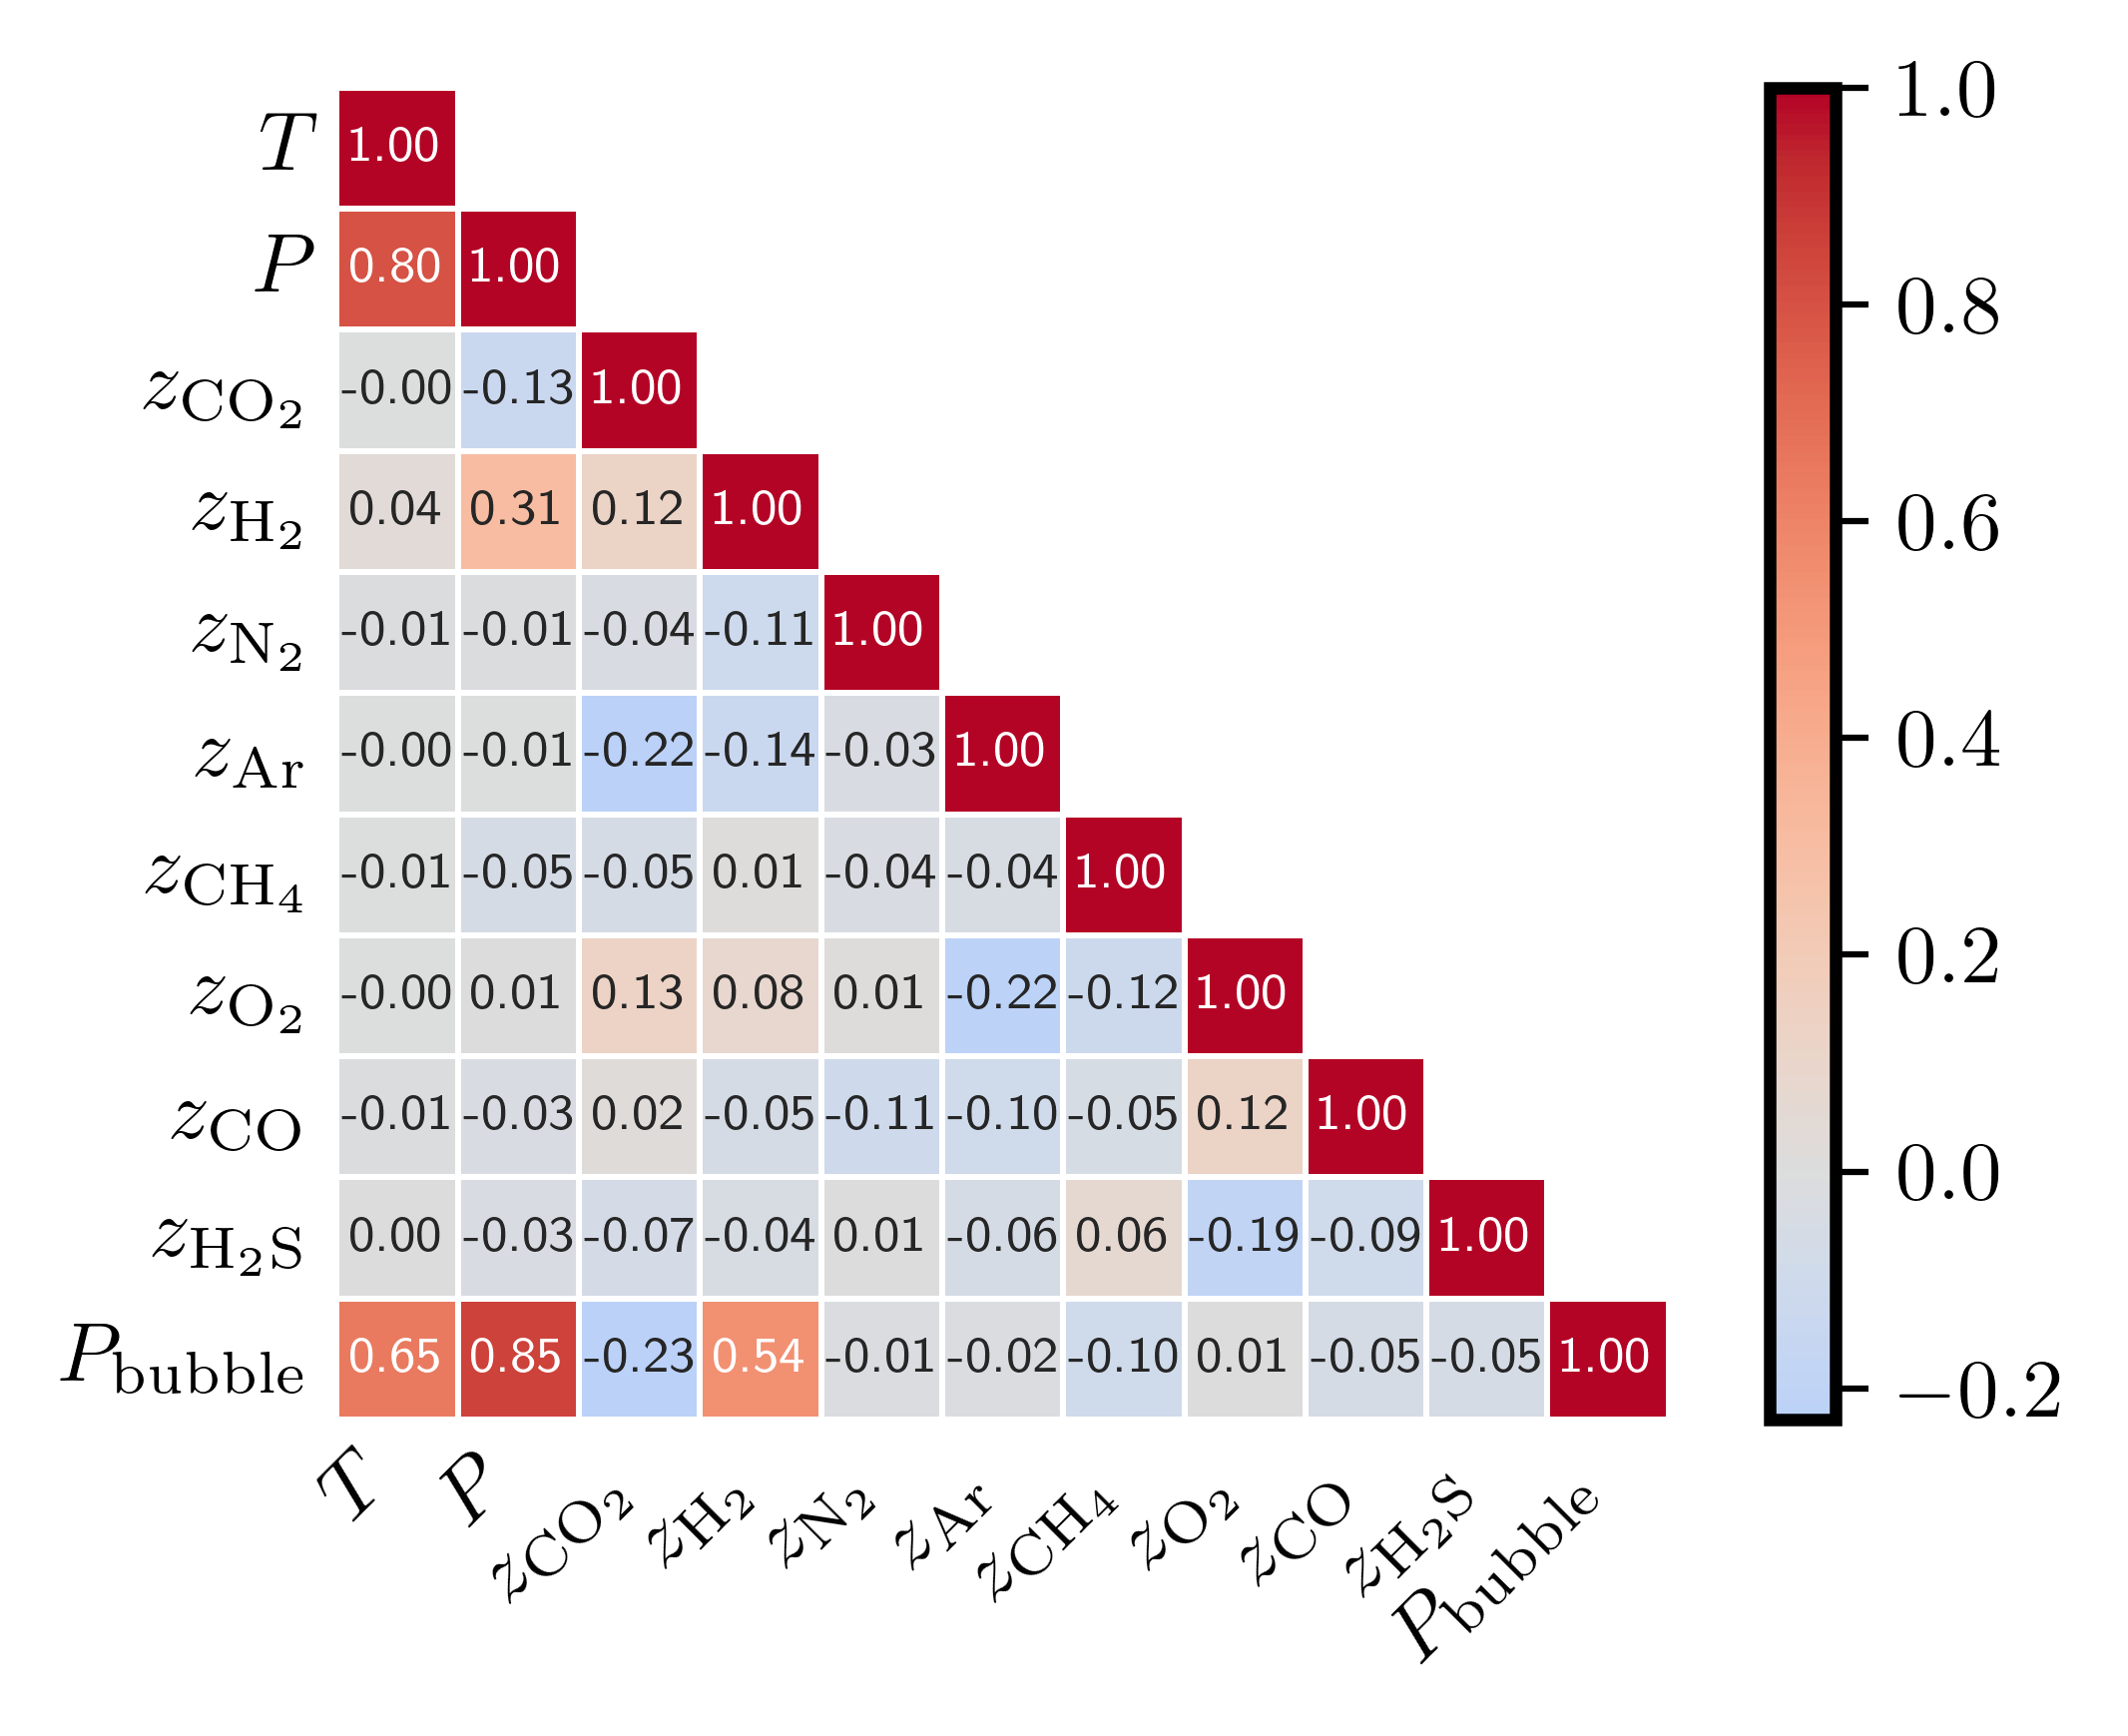

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="SVM_P_bubble_correlation", folder=OUTPUT_FOLDER)

In [7]:
# Train SVM model (SVR)
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="linear",    # radial basis function — best general-purpose kernel
        C=100,              # regularisation: higher = tighter fit, lower = smoother
        epsilon=0.1,        # insensitive tube half-width (in scaled units)
        # gamma="scale",      # 1 / (n_features * X.var()), auto-tuned
    ))
])

svm_model.fit(X_train, y_train)

y_train_pred    = svm_model.predict(X_train)
y_test_pred     = svm_model.predict(X_test)
y_val_pred      = svm_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_bubble

Training Set:
  R²:   0.855378
  RMSE: 8.006687 bar
  MAE:  4.466709 bar

Test Set:
  R²:   0.813192
  RMSE: 9.456108 bar
  MAE:  4.849878 bar

Validation Set:
  R²:   0.845359
  RMSE: 8.321787 bar
  MAE:  4.573311 bar


In [8]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"SVM_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"SVM_{target}_model.joblib")
joblib.dump(svm_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: SLURM_Pbubble/SVM_P_bubble_model.joblib


In [9]:
# 5-fold cross-validation
cv_results = cross_validate(
    svm_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
    },
    n_jobs=n_cpus,
)
cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]
cv_mape_scores = -cv_results["test_mape"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE: {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.87675302 0.83314137 0.81823087 0.86432778 0.85427106]
Mean CV R²:   0.849345 (+/- 0.042243)

Cross-Validation RMSE Scores: [7.07001157 9.54773768 9.43187715 7.63165505 7.29847211]
Mean CV RMSE: 8.195951 (+/- 2.144104)

Cross-Validation MAE Scores:  [4.10448057 4.72973793 5.15731746 4.29982924 4.47066144]
Mean CV MAE:  4.552405 (+/- 0.731289)

Cross-Validation MAPE Scores: [10.50795021 10.70829482 11.12927199 10.25181094 10.77258109]
Mean CV MAPE: 10.6740% (+/- 0.5824%)


C sweep complete.
  C=   0.01 | Train RMSE=8.1599  Test RMSE=9.6066  SVs=13272
  C=    0.1 | Train RMSE=8.0178  Test RMSE=9.4657  SVs=13266
  C=      1 | Train RMSE=8.0065  Test RMSE=9.4558  SVs=13251
  C=     10 | Train RMSE=8.0067  Test RMSE=9.4559  SVs=13256
  C=    100 | Train RMSE=8.0067  Test RMSE=9.4561  SVs=13253
  C=    500 | Train RMSE=8.0066  Test RMSE=9.4560  SVs=13256
  C=   1000 | Train RMSE=8.0074  Test RMSE=9.4570  SVs=13258
  C=   5000 | Train RMSE=8.0054  Test RMSE=9.4540  SVs=13264


/tmp/ipykernel_920775/146348782.py:42: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:227: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(file_path, dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:228: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(fr"{filename}", dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/py_A6/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


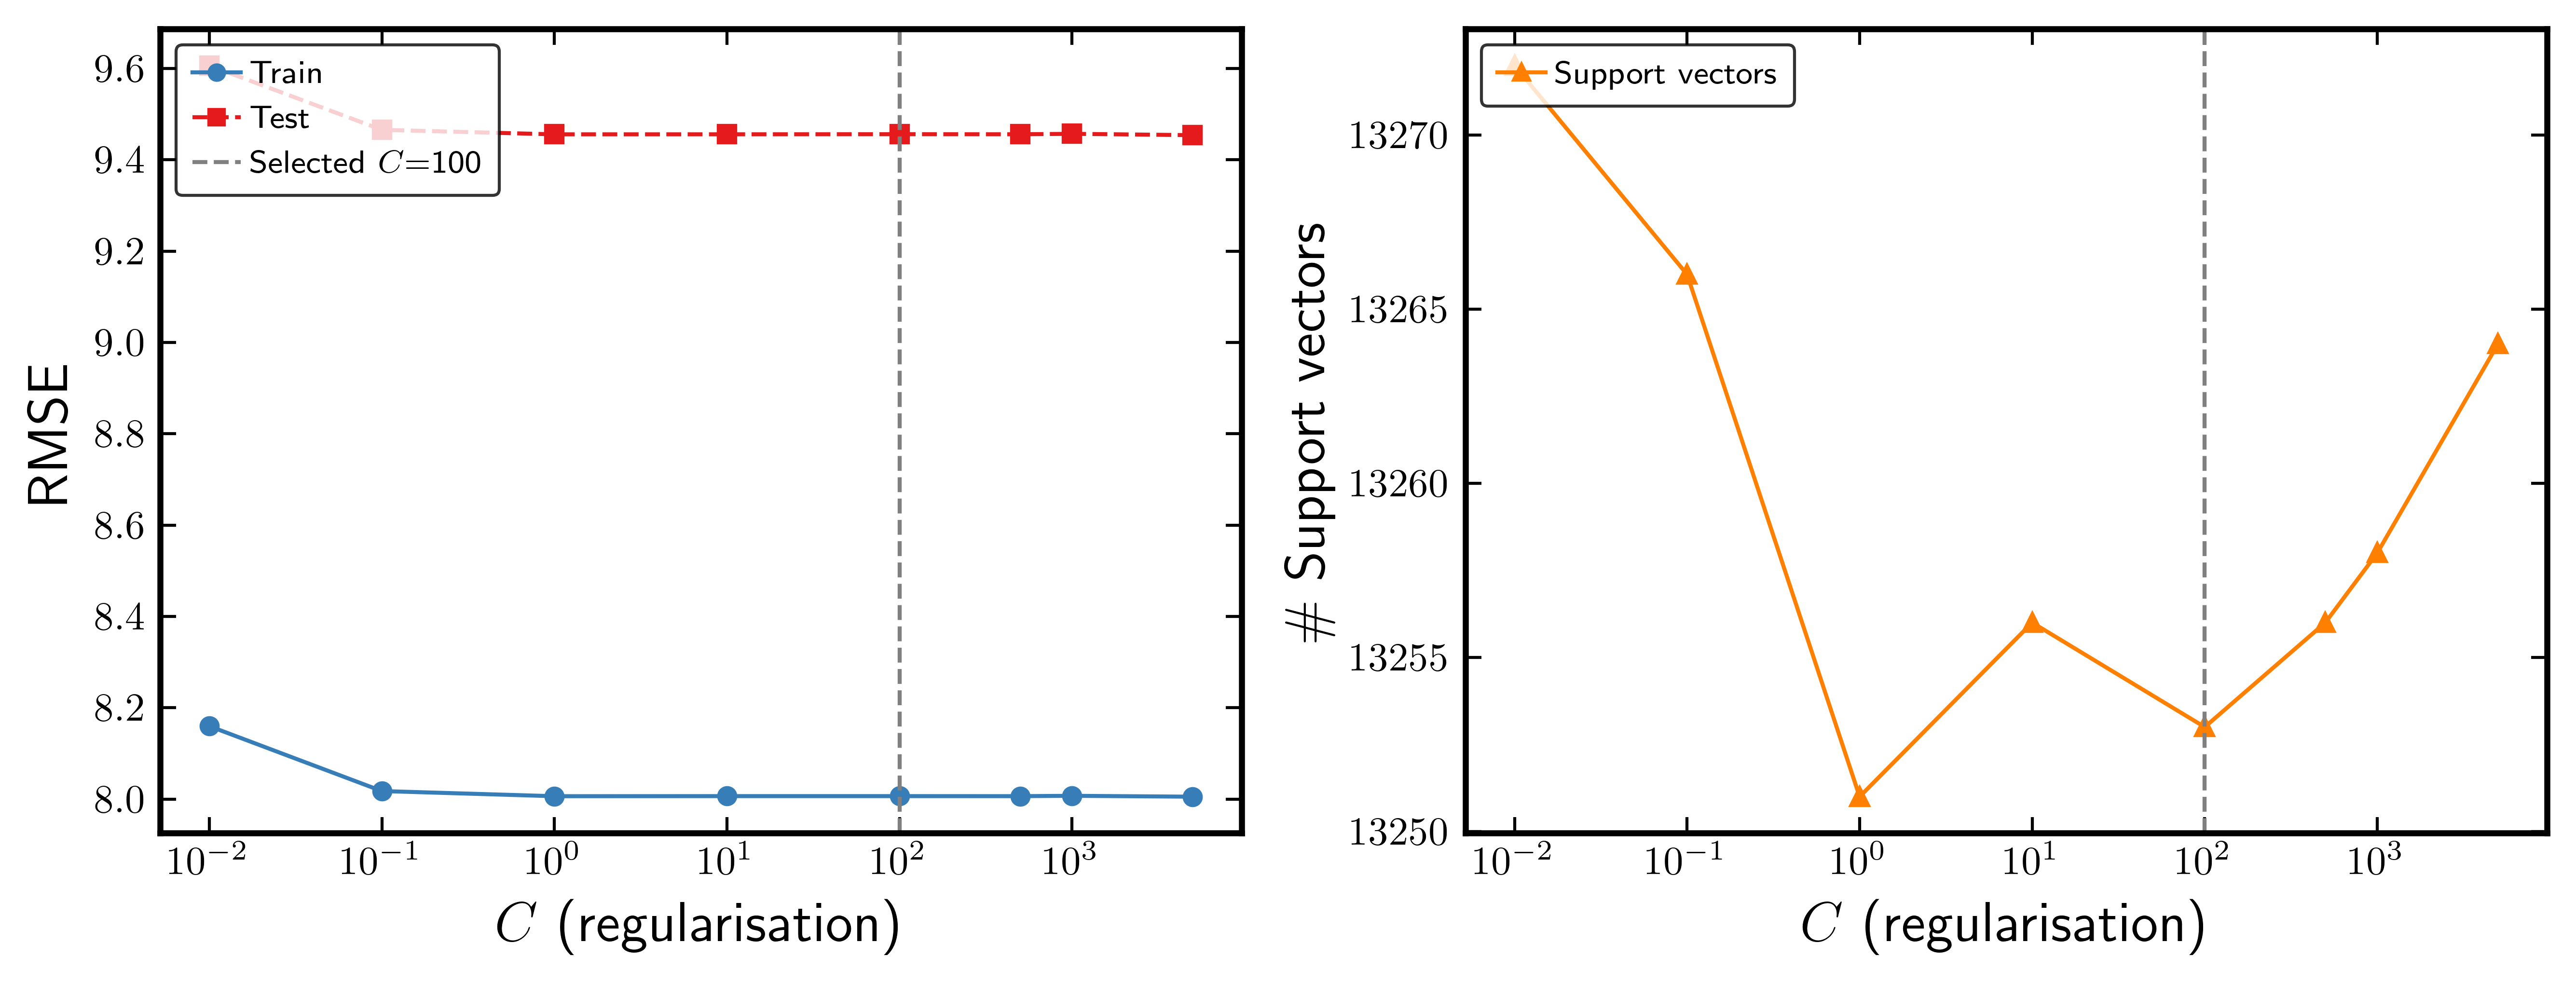

Saved: SVM_P_bubble_C_sweep


In [10]:
# Hyperparameter analysis: C sensitivity sweep (Linear SVR)

C_values = [0.01, 0.1, 1, 10, 100, 500, 1000, 5000]
_scaler = StandardScaler()
X_tr_sc = _scaler.fit_transform(X_train)
X_te_sc = _scaler.transform(X_test)

train_rmse_C, test_rmse_C, sv_count_C = [], [], []
for _C in C_values:
    _SVR = SVR(kernel="linear", C=_C, epsilon=0.1)
    _SVR.fit(X_tr_sc, y_train)
    train_rmse_C.append(np.sqrt(mean_squared_error(y_train, _SVR.predict(X_tr_sc))))
    test_rmse_C.append(np.sqrt(mean_squared_error(y_test,  _SVR.predict(X_te_sc))))
    sv_count_C.append(_SVR.support_vectors_.shape[0])
print("C sweep complete.")
for _C, tr, te, sv in zip(C_values, train_rmse_C, test_rmse_C, sv_count_C):
    print(f"  C={_C:>7} | Train RMSE={tr:.4f}  Test RMSE={te:.4f}  SVs={sv}")

# Plot: RMSE left axis, SV count right axis
fig, axes = ps.plot_init_multi(1, 2, w=9, h=3.5)
ax_rmse, ax_sv = axes

ax_rmse.semilogx(C_values, train_rmse_C, marker="o", markersize=ps.markersize,
                 lw=ps.linewidth, color=ps.colors[2], label="Train")
ax_rmse.semilogx(C_values, test_rmse_C,  marker="s", markersize=ps.markersize,
                 lw=ps.linewidth, color=ps.colors[0], label="Test")
ax_rmse.axvline(svm_model.named_steps["svr"].C, ls="--", color="gray",
                lw=ps.linewidth, label=f'Selected $C$={svm_model.named_steps["svr"].C}')
ax_rmse.set_xlabel(r"$C$ (regularisation)", fontsize=ps.label_fontsize)
ax_rmse.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax_rmse.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_rmse, loc="upper left")

ax_sv.semilogx(C_values, sv_count_C, marker="^", markersize=ps.markersize,
               lw=ps.linewidth, color=ps.colors[3], label="Support vectors")
ax_sv.axvline(svm_model.named_steps["svr"].C, ls="--", color="gray", lw=ps.linewidth)
ax_sv.set_xlabel(r"$C$ (regularisation)", fontsize=ps.label_fontsize)
ax_sv.set_ylabel(r"\# Support vectors", fontsize=ps.label_fontsize)
ax_sv.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_sv, loc="upper left")

plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_C_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_C_sweep")

Epsilon sweep complete.
  eps=0.001 | Train RMSE=7.9984  Test RMSE=9.4462  SVs=13549
  eps=0.005 | Train RMSE=7.9992  Test RMSE=9.4469  SVs=13538
  eps=0.010 | Train RMSE=7.9991  Test RMSE=9.4471  SVs=13523
  eps=0.050 | Train RMSE=8.0019  Test RMSE=9.4505  SVs=13396
  eps=0.100 | Train RMSE=8.0067  Test RMSE=9.4561  SVs=13253
  eps=0.500 | Train RMSE=7.9955  Test RMSE=9.4415  SVs=12175
  eps=1.000 | Train RMSE=7.9868  Test RMSE=9.4371  SVs=10771
  eps=2.000 | Train RMSE=7.9463  Test RMSE=9.4006  SVs=8408


/tmp/ipykernel_920775/2175866796.py:40: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:227: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(file_path, dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:228: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(fr"{filename}", dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/py_A6/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


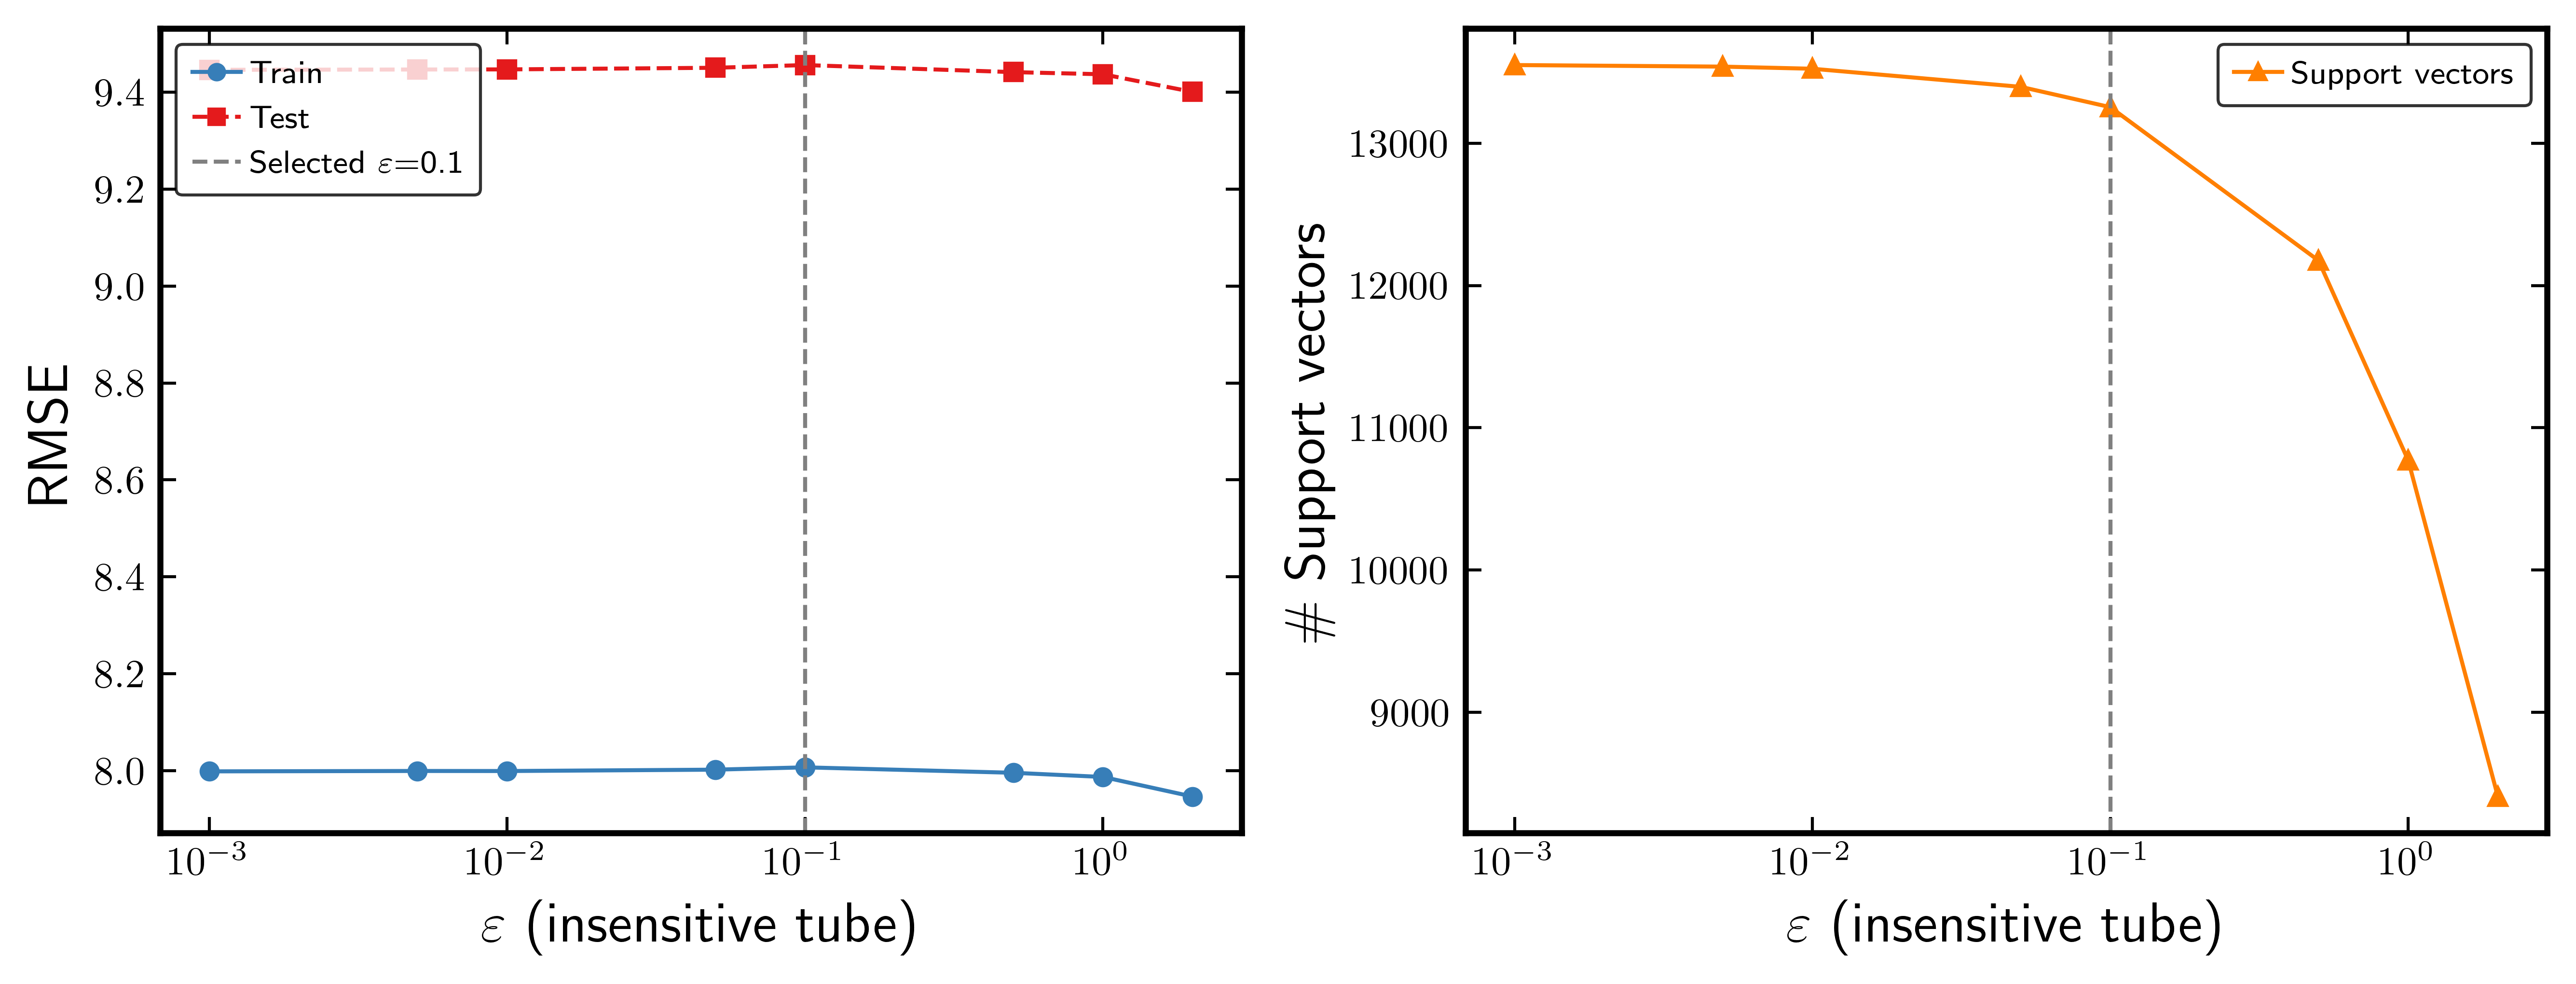

Saved: SVM_P_bubble_epsilon_sweep


In [11]:
# Hyperparameter analysis: epsilon sensitivity sweep (Linear SVR)
eps_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
C_fixed    = svm_model.named_steps["svr"].C

# Reuse the same scaler fitted in C sweep
train_rmse_eps, test_rmse_eps, sv_count_eps = [], [], []
for _eps in eps_values:
    _SVR = SVR(kernel="linear", C=C_fixed, epsilon=_eps)
    _SVR.fit(X_tr_sc, y_train)
    train_rmse_eps.append(np.sqrt(mean_squared_error(y_train, _SVR.predict(X_tr_sc))))
    test_rmse_eps.append(np.sqrt(mean_squared_error(y_test,  _SVR.predict(X_te_sc))))
    sv_count_eps.append(_SVR.support_vectors_.shape[0])
print("Epsilon sweep complete.")
for _e, tr, te, sv in zip(eps_values, train_rmse_eps, test_rmse_eps, sv_count_eps):
    print(f"  eps={_e:.3f} | Train RMSE={tr:.4f}  Test RMSE={te:.4f}  SVs={sv}")

fig, axes = ps.plot_init_multi(1, 2, w=9, h=3.5)
ax_r, ax_s = axes

ax_r.semilogx(eps_values, train_rmse_eps, marker="o", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[2], label="Train")
ax_r.semilogx(eps_values, test_rmse_eps,  marker="s", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[0], label="Test")
ax_r.axvline(svm_model.named_steps["svr"].epsilon, ls="--", color="gray",
             lw=ps.linewidth,
             label=rf'Selected $\varepsilon$={svm_model.named_steps["svr"].epsilon}')
ax_r.set_xlabel(r"$\varepsilon$ (insensitive tube)", fontsize=ps.label_fontsize)
ax_r.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax_r.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_r, loc="upper left")

ax_s.semilogx(eps_values, sv_count_eps, marker="^", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[3], label="Support vectors")
ax_s.axvline(svm_model.named_steps["svr"].epsilon, ls="--", color="gray", lw=ps.linewidth)
ax_s.set_xlabel(r"$\varepsilon$ (insensitive tube)", fontsize=ps.label_fontsize)
ax_s.set_ylabel(r"\# Support vectors", fontsize=ps.label_fontsize)
ax_s.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_s, loc="upper right")

plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_epsilon_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_epsilon_sweep")

Outlier threshold (3σ): ±24.617640
Test outliers: 73/2904 (2.51%)
Val  outliers: 57/2905  (1.96%)
Saved: SVM_P_bubble_outliers.csv (130 rows)
  idx split  source_id  temperature  pressure     actual  predicted   residual
15341  test         79        220.0  6.808294 103.464478  51.942929  51.521549
 7748  test         40        200.0  7.242061  44.016768  16.464450  27.552318
  382  test          2        200.0 16.326407  64.014339  31.716157  32.298182
 9684  test         50        200.0 55.556597 121.635785  63.027231  58.608553
 8146  test         42        205.0 15.605196 112.571014  48.112478  64.458536
 7373  test         38        205.0 30.423064  84.339857  48.448868  35.890989
 4648  test         24        205.0 23.629725  94.263072  43.273495  50.989577
 7381  test         38        210.0 12.644119  78.807667  39.283643  39.524023
15332  test         79        215.0  5.517150 110.062042  50.278707  59.783335
 9727  test         50        225.0 15.601297  75.232585  44.992634 

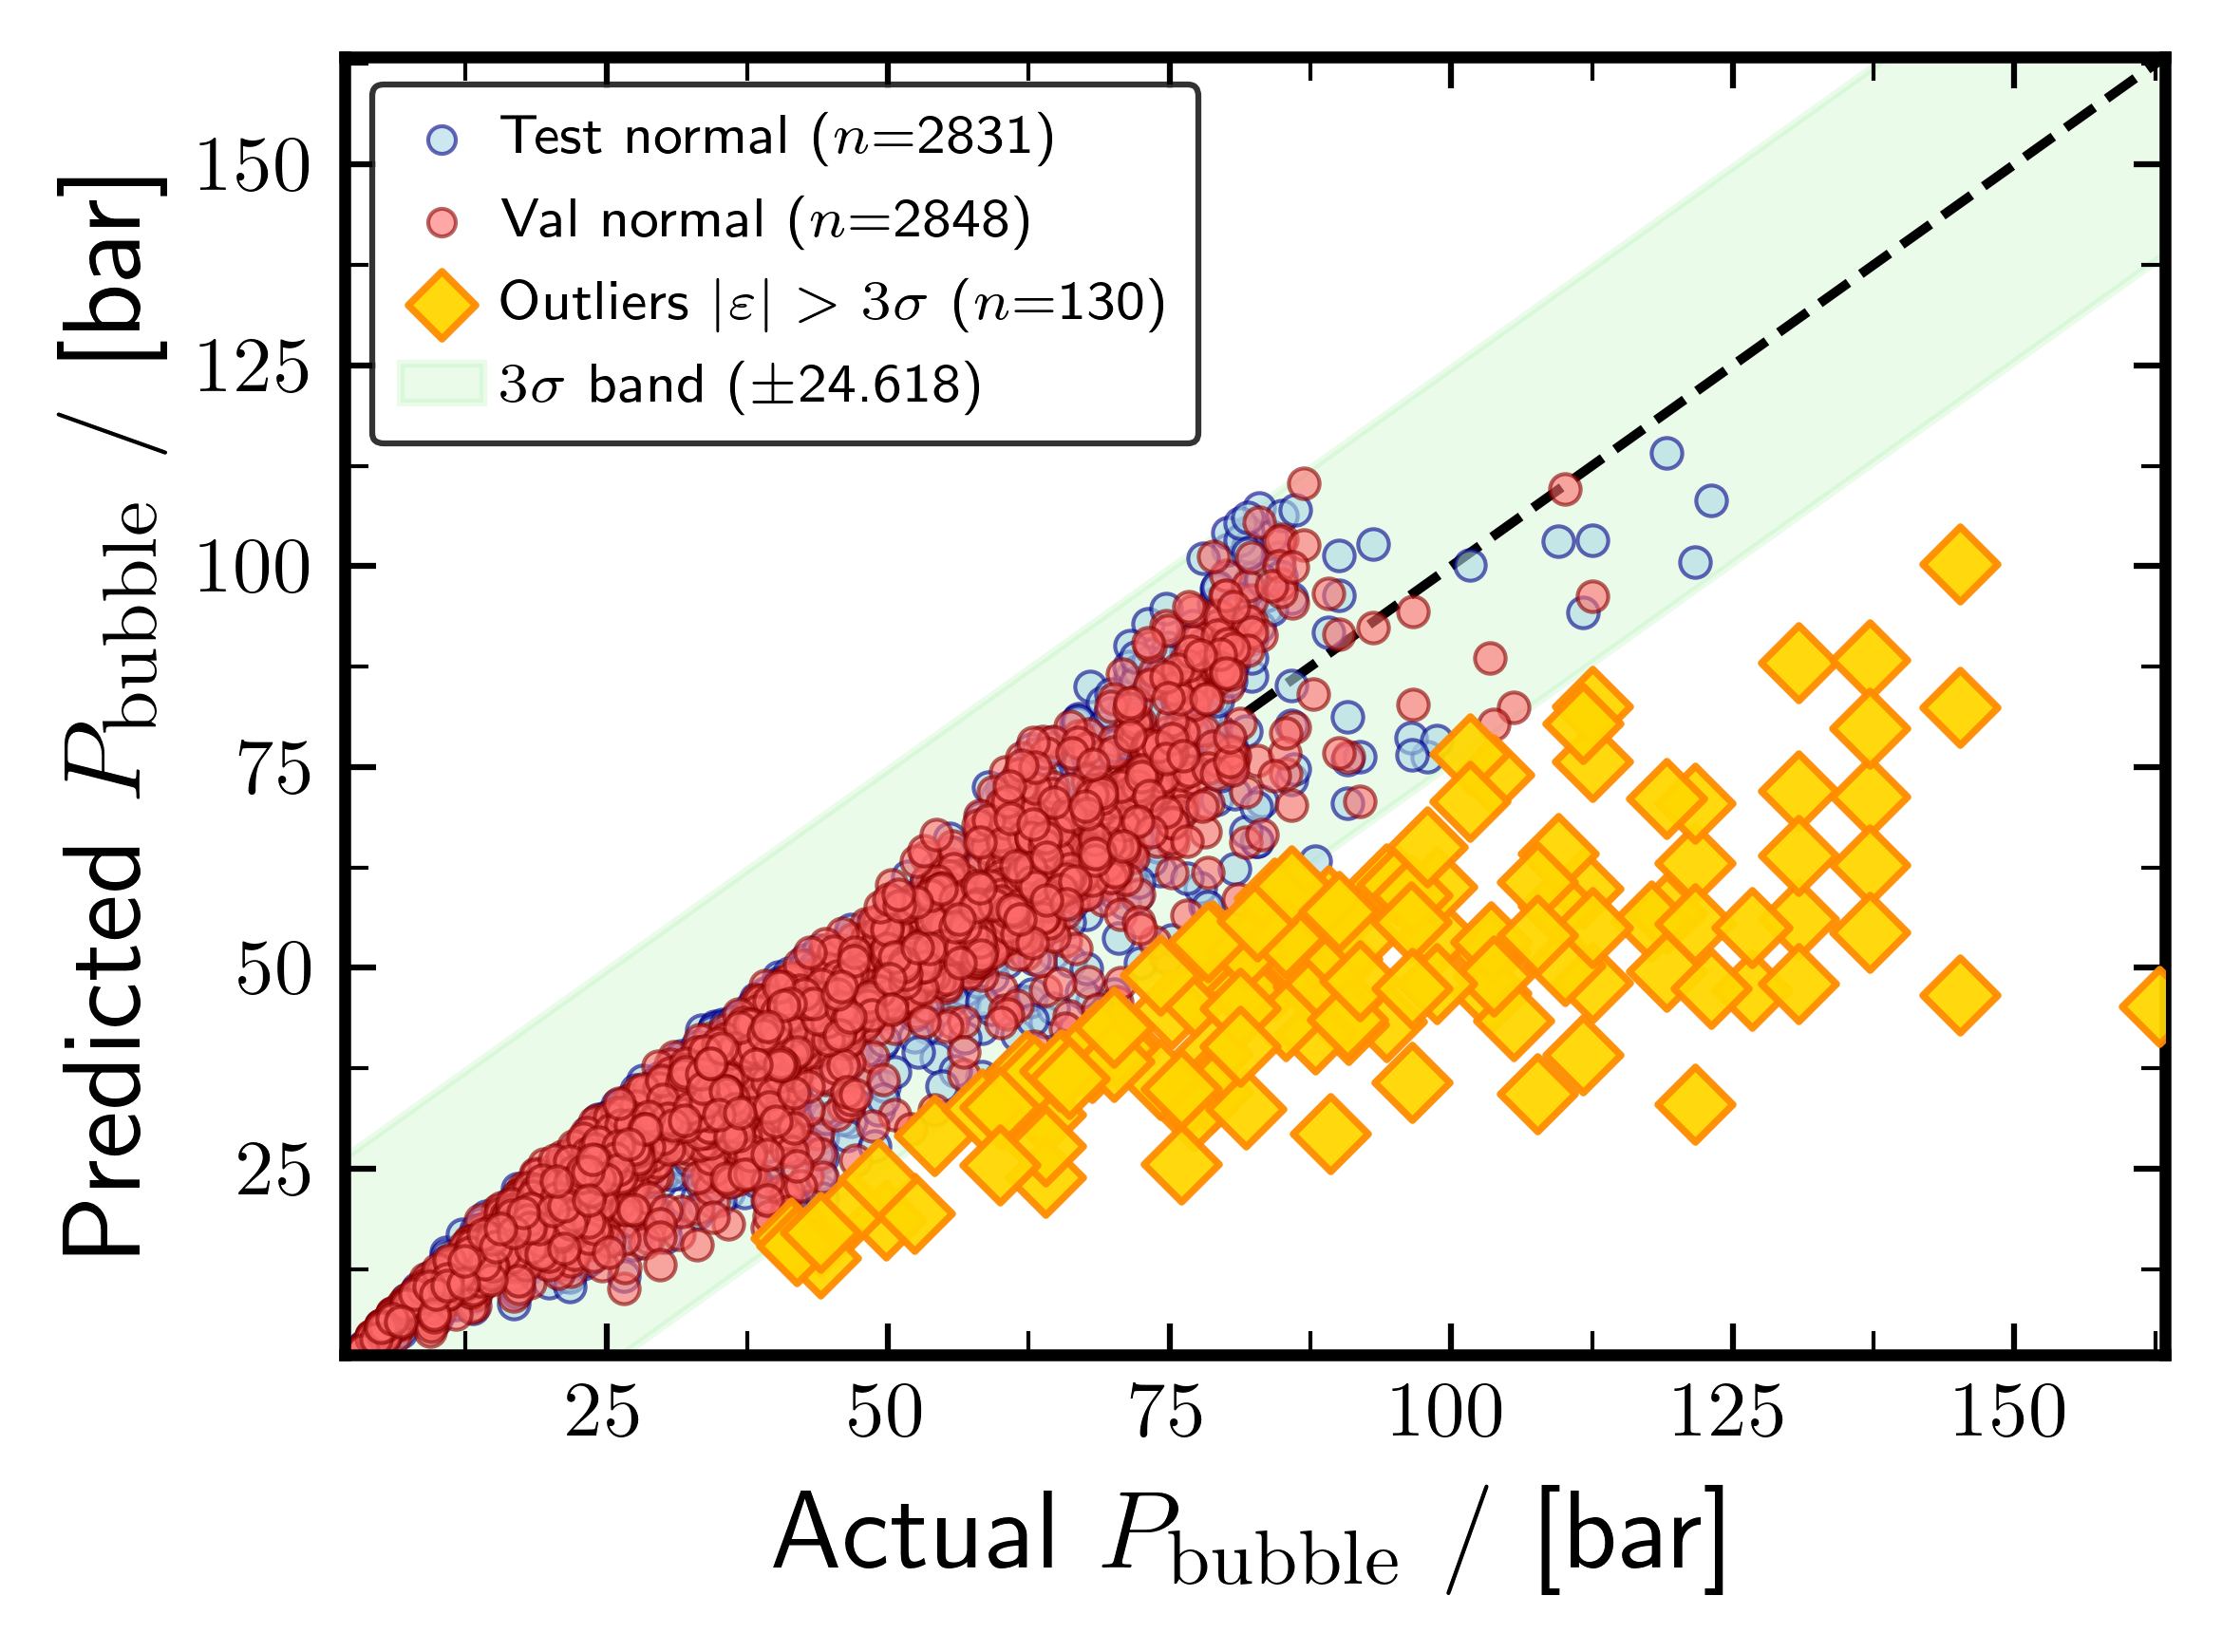

Saved: SVM_P_bubble_outlier_parity


In [12]:
# Outlier flagging: test + val samples where |residual| > 3 * global std

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3\u03c3): \u00b1{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"SVM_{target}_outliers.csv"), index=False)
print(f"Saved: SVM_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=45, facecolors="gold", edgecolors="darkorange",
        linewidths=0.9, marker="D", zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_outlier_parity")

In [13]:
# coef_ as a direct importance
coef_importance = pd.Series(
    np.abs(svm_model.named_steps["svr"].coef_[0]),
    index=features
).sort_values(ascending=False)

print("\nDirect Coefficient Importance (|coef_|):")
print(coef_importance.to_string())


Direct Coefficient Importance (|coef_|):
pressure              11.043710
z_hydrogen             8.165327
temperature            5.216584
z_carbon dioxide       3.495267
z_hydrogen sulfide     1.850728
z_methane              1.197416
z_nitrogen             0.976382
z_argon                0.289959
z_oxygen               0.080406
z_carbon monoxide      0.039246


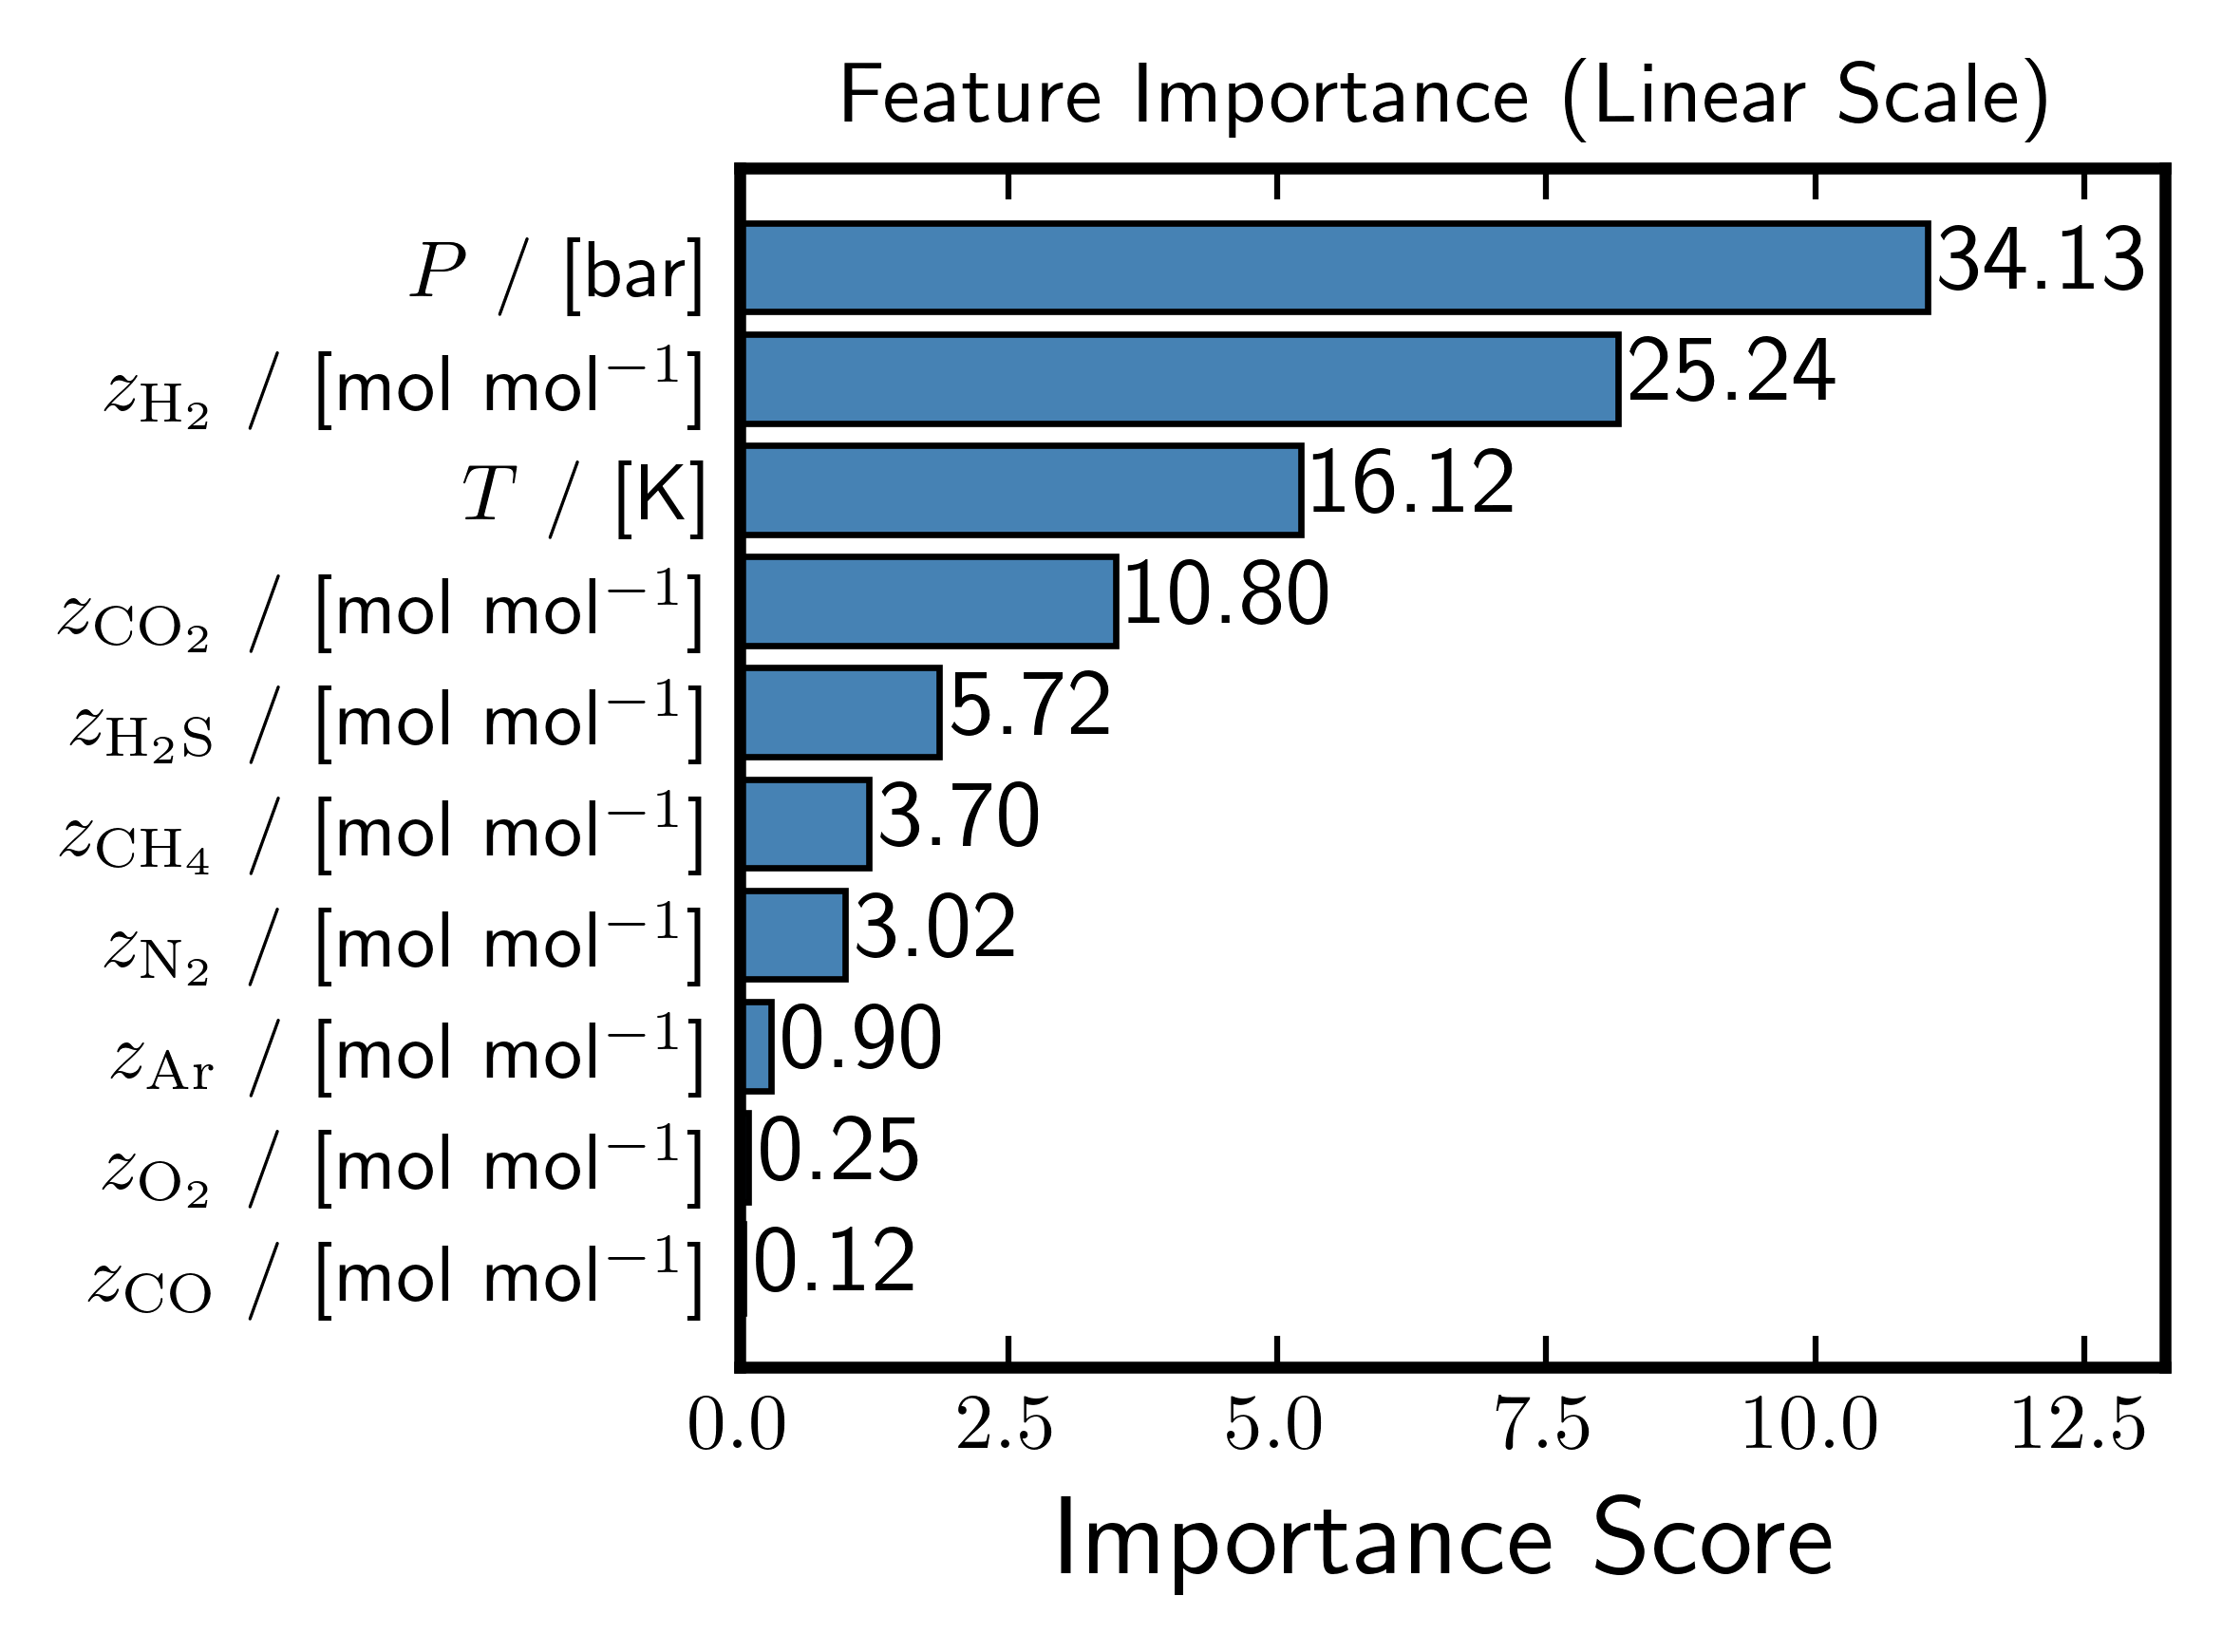

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [14]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=np.abs(svm_model.named_steps["svr"].coef_[0]),
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="SVM_P_bubble_feature_importance_linear", folder=OUTPUT_FOLDER)

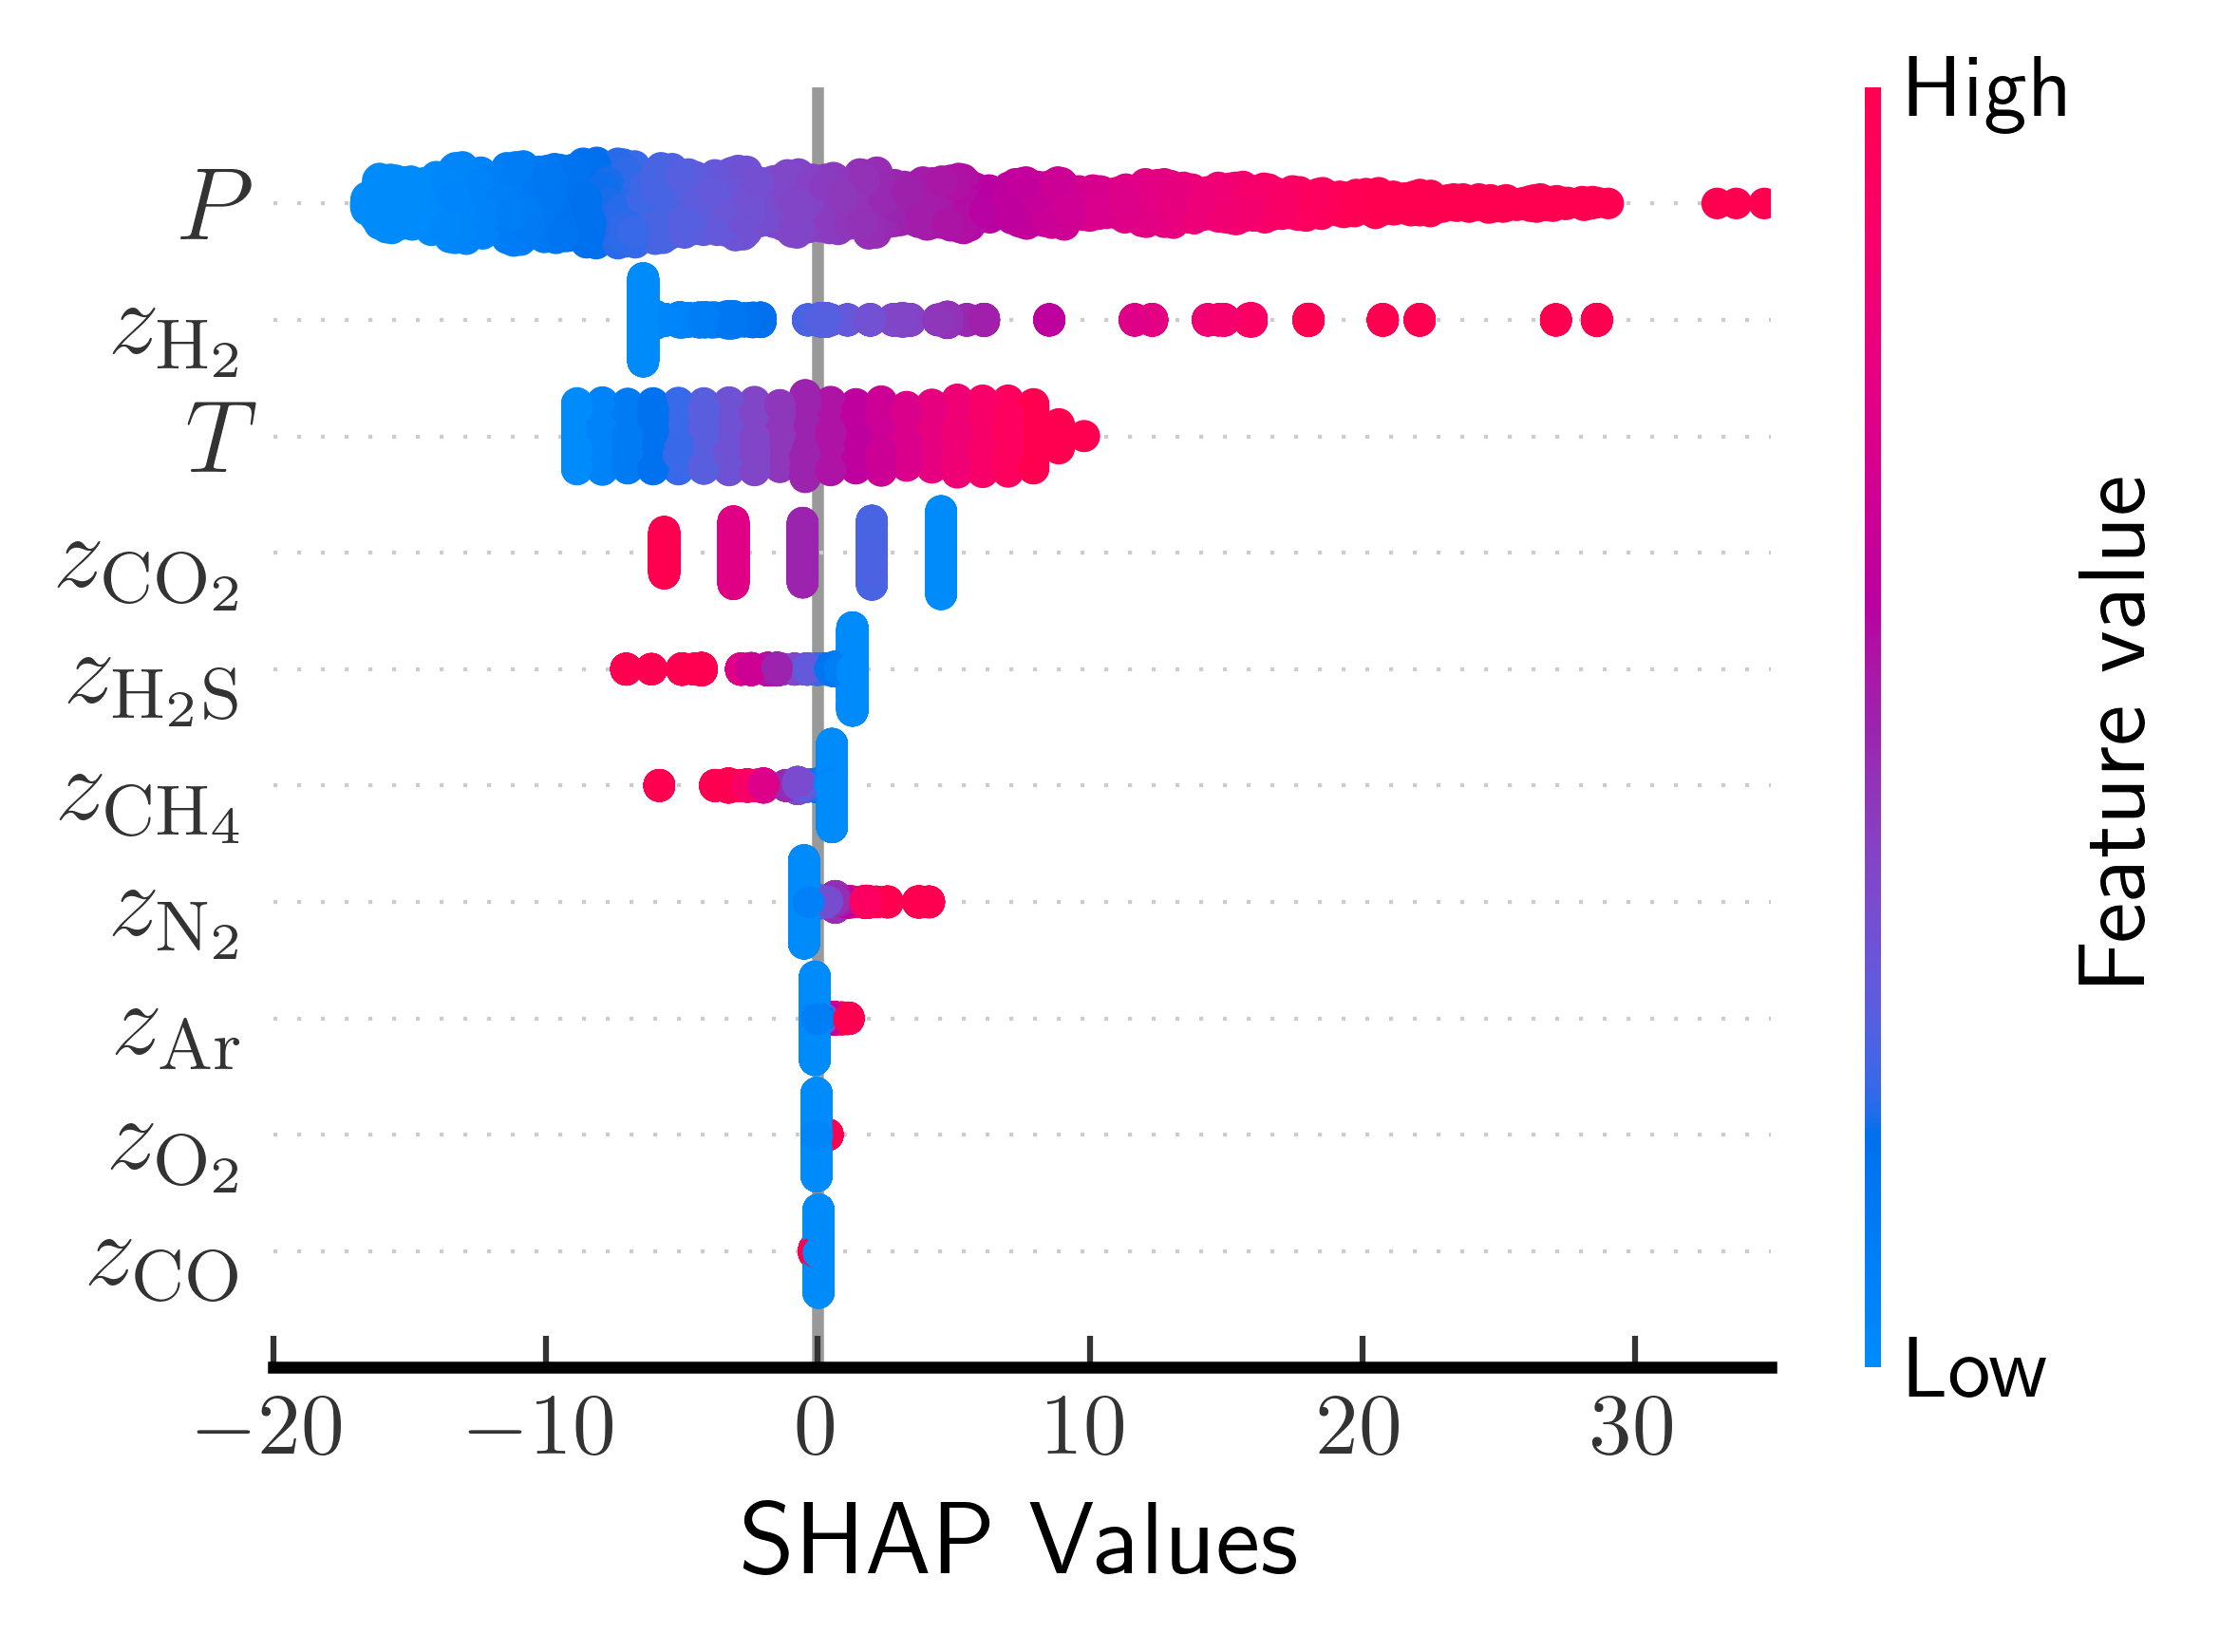

In [15]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "P_bubble": r"$P_{\mathrm{bubble}}$",
}

# SHAP Values - SVM
scaler          = svm_model.named_steps["scaler"]
svr_step        = svm_model.named_steps["svr"]
X_train_scaled  = scaler.transform(X_train)
X_test_scaled   = scaler.transform(X_test)

explainer       = shap.LinearExplainer(svr_step, X_train_scaled)
shap_values     = explainer.shap_values(X_test_scaled)

feature_labels  = [label_map.get(f, f) for f in features]
shap_df         = pd.DataFrame(shap_values, columns=feature_labels)

# Beeswarm Summary Plot
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_labels,
    show=False,
    plot_size=None)

ax = plt.gca()
ax.set_xlabel("SHAP Values")
ax.set_xticks(np.arange(-20, 35, 10))   # start, stop, step
ax.set_xlim(-20, 35)

plt.tight_layout()
ps.save_plot(fig, "SVM_linear_P_bubble_shap_summary")
plt.show()

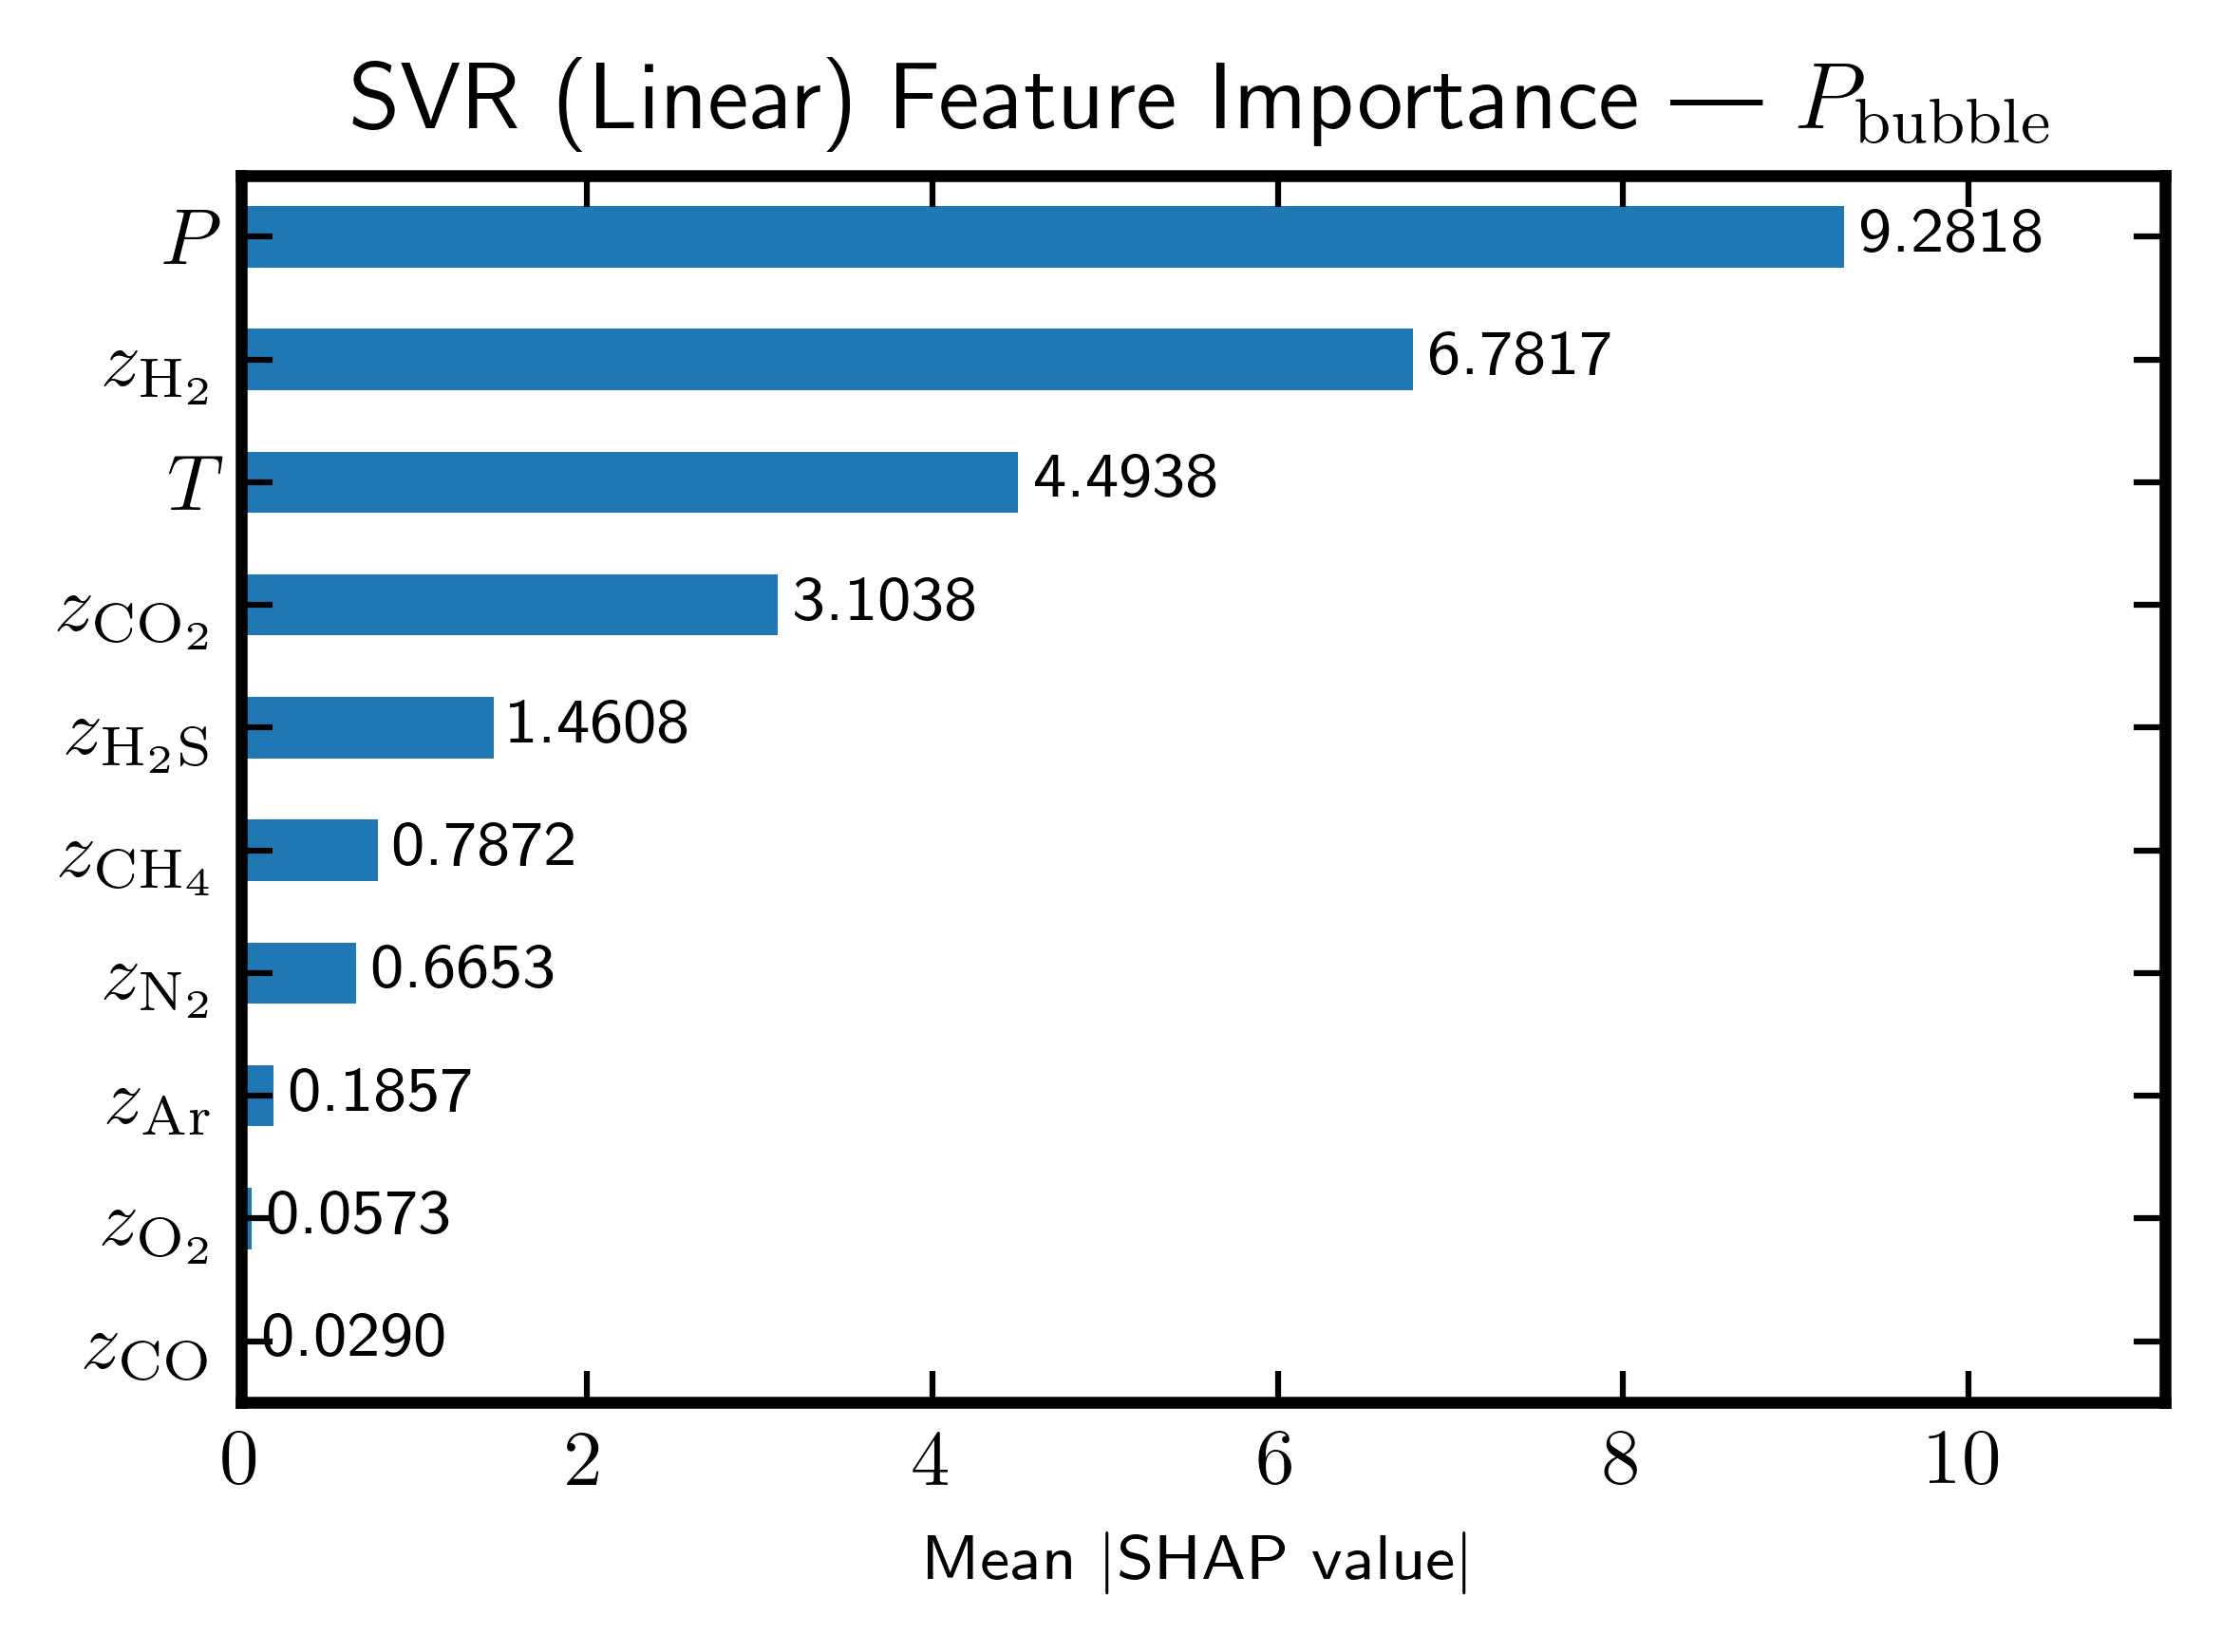

In [16]:
# Plot 2: Mean |SHAP| Bar Chart
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=True)

fig, ax = ps.plot_init()
mean_abs_shap.plot(kind="barh", ax=ax)

# Annotate each bar with its exact value
for i, val in enumerate(mean_abs_shap):
    ax.text(
        val + 0.01 * mean_abs_shap.max(),  # small offset from bar tip
        i,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )

# Expand x-axis slightly so labels don't get clipped
ax.set_xlim(0, mean_abs_shap.max() * 1.20)

ax.set_xlabel(r"Mean $|$SHAP value$|$")
ax.set_title(r"SVR (Linear) Feature Importance — $P_{\mathrm{bubble}}$")
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, "SVR_linear_P_bubble_shap_bar")
plt.show()

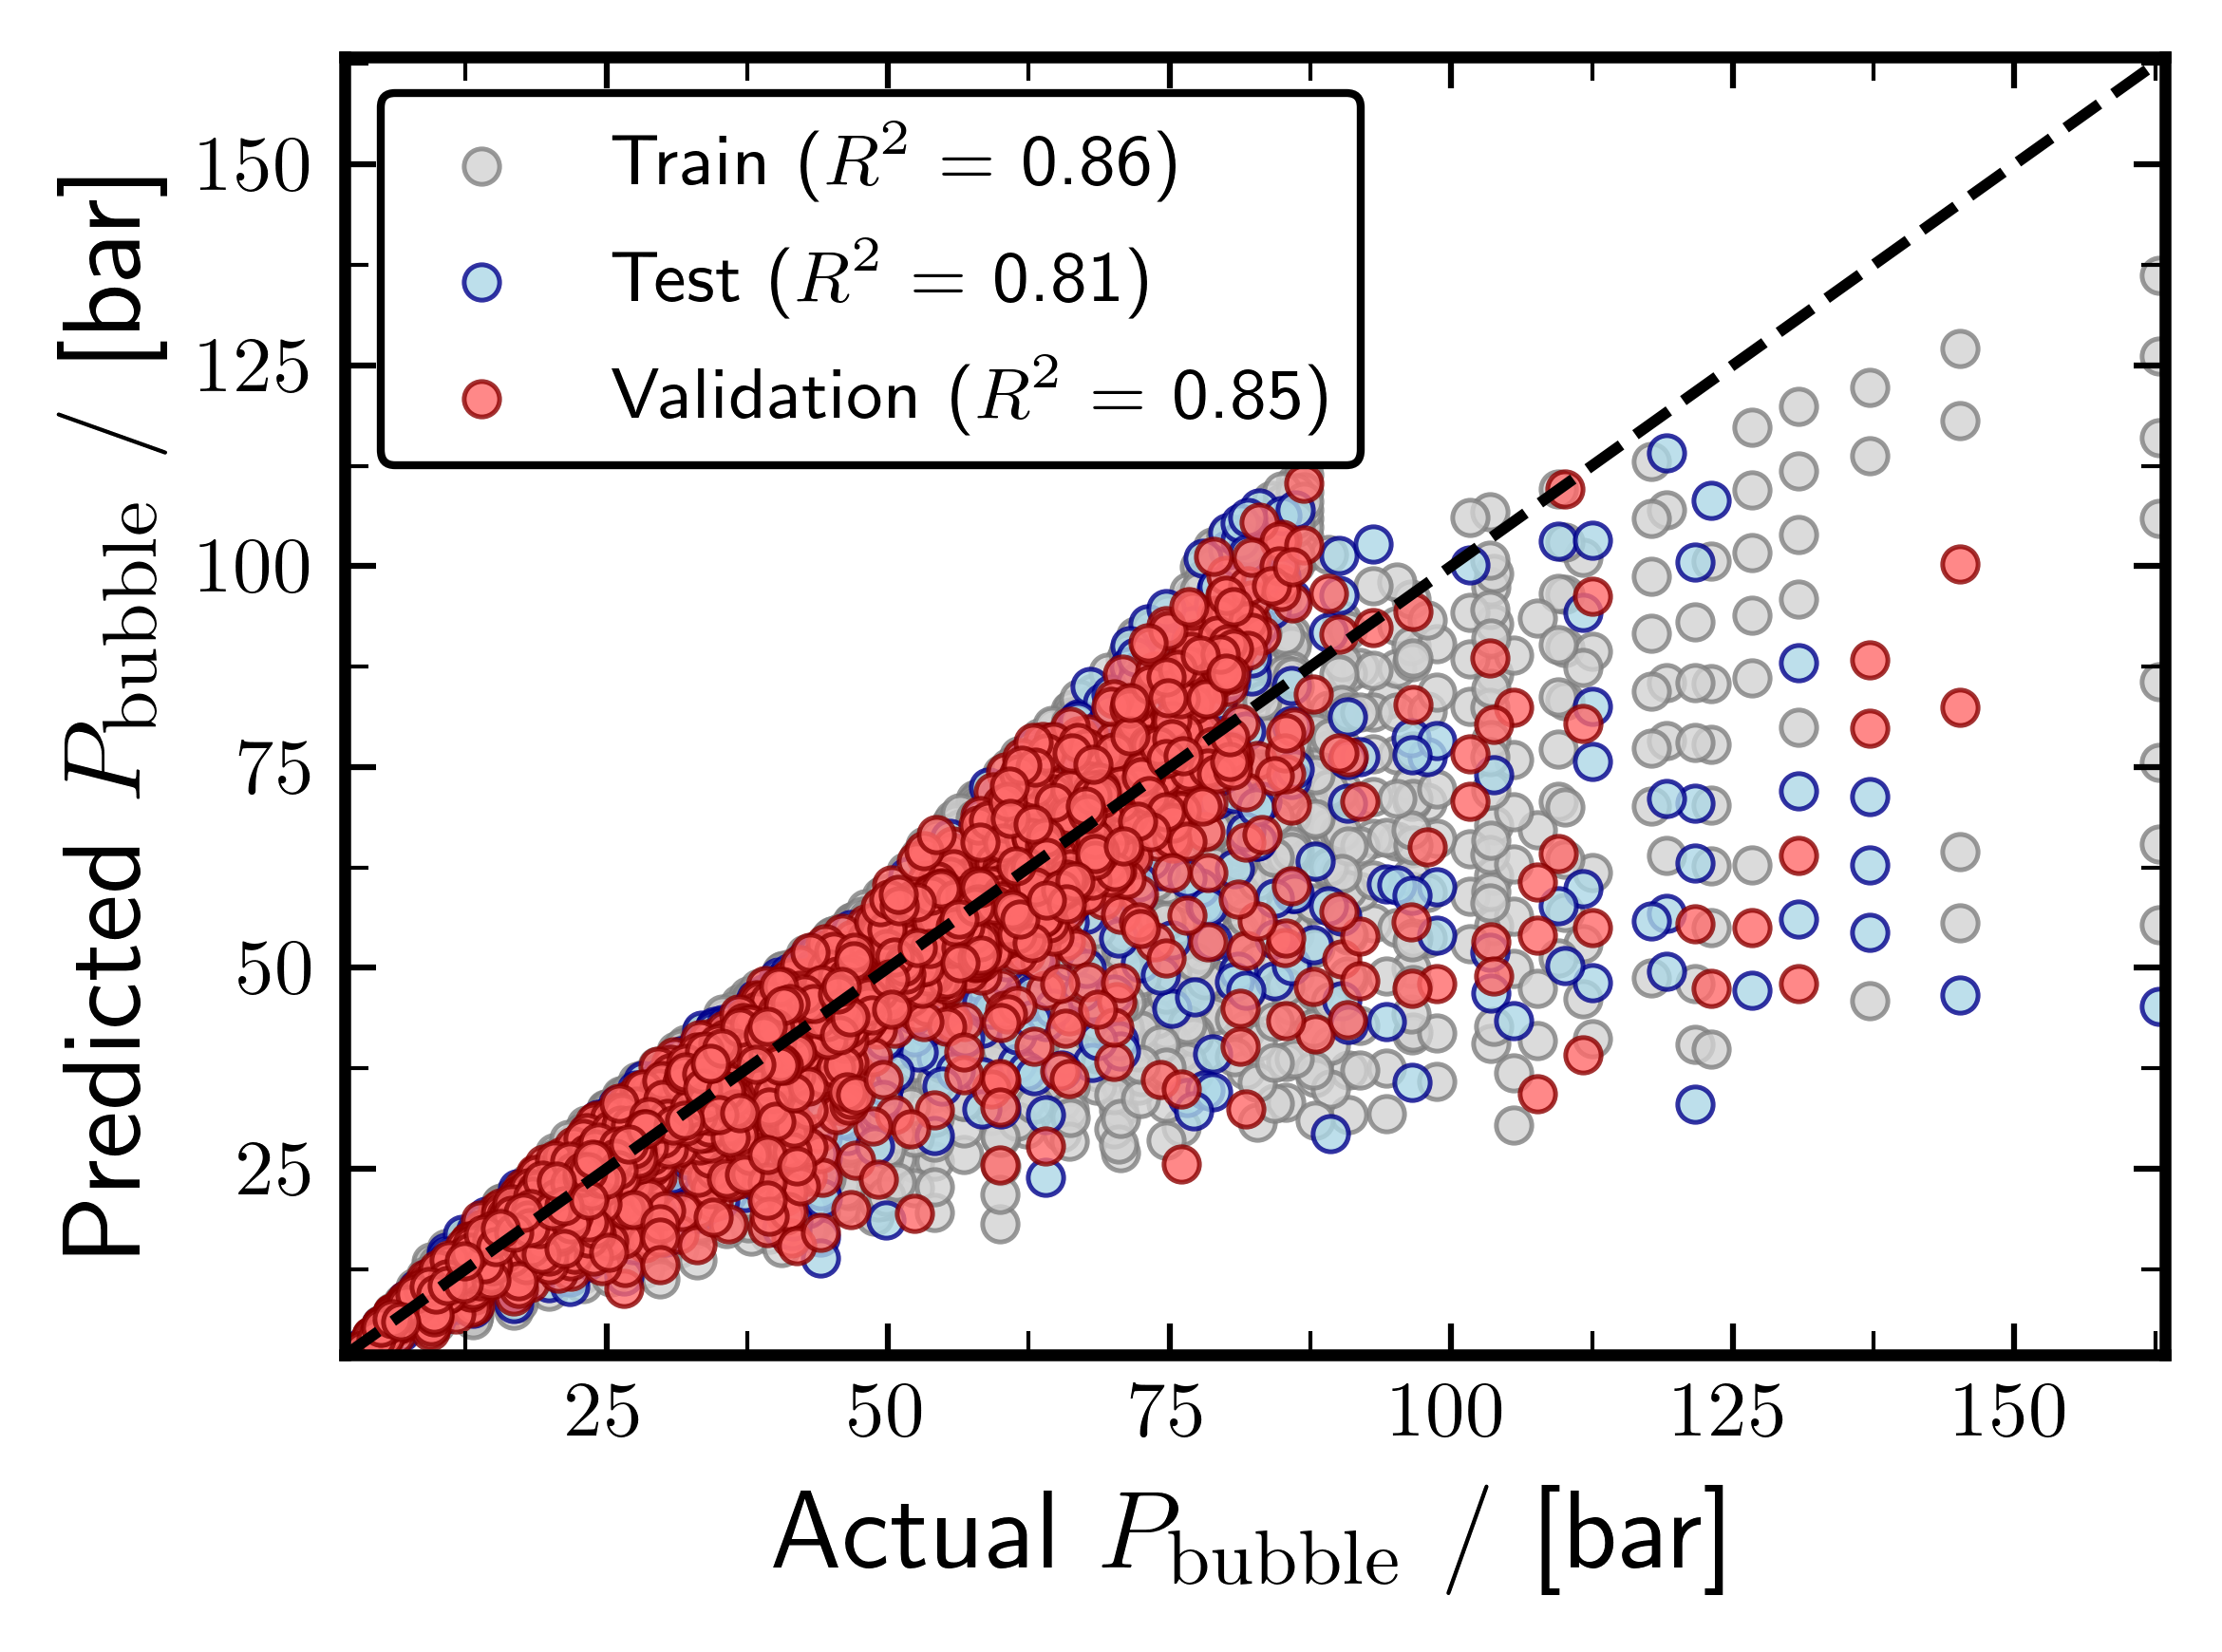

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]'>)

In [17]:
# Parity plot
post.plot_parity(model_name="SVR (Linear)", save_path="SVM_P_bubble_parity_plot", folder=OUTPUT_FOLDER)

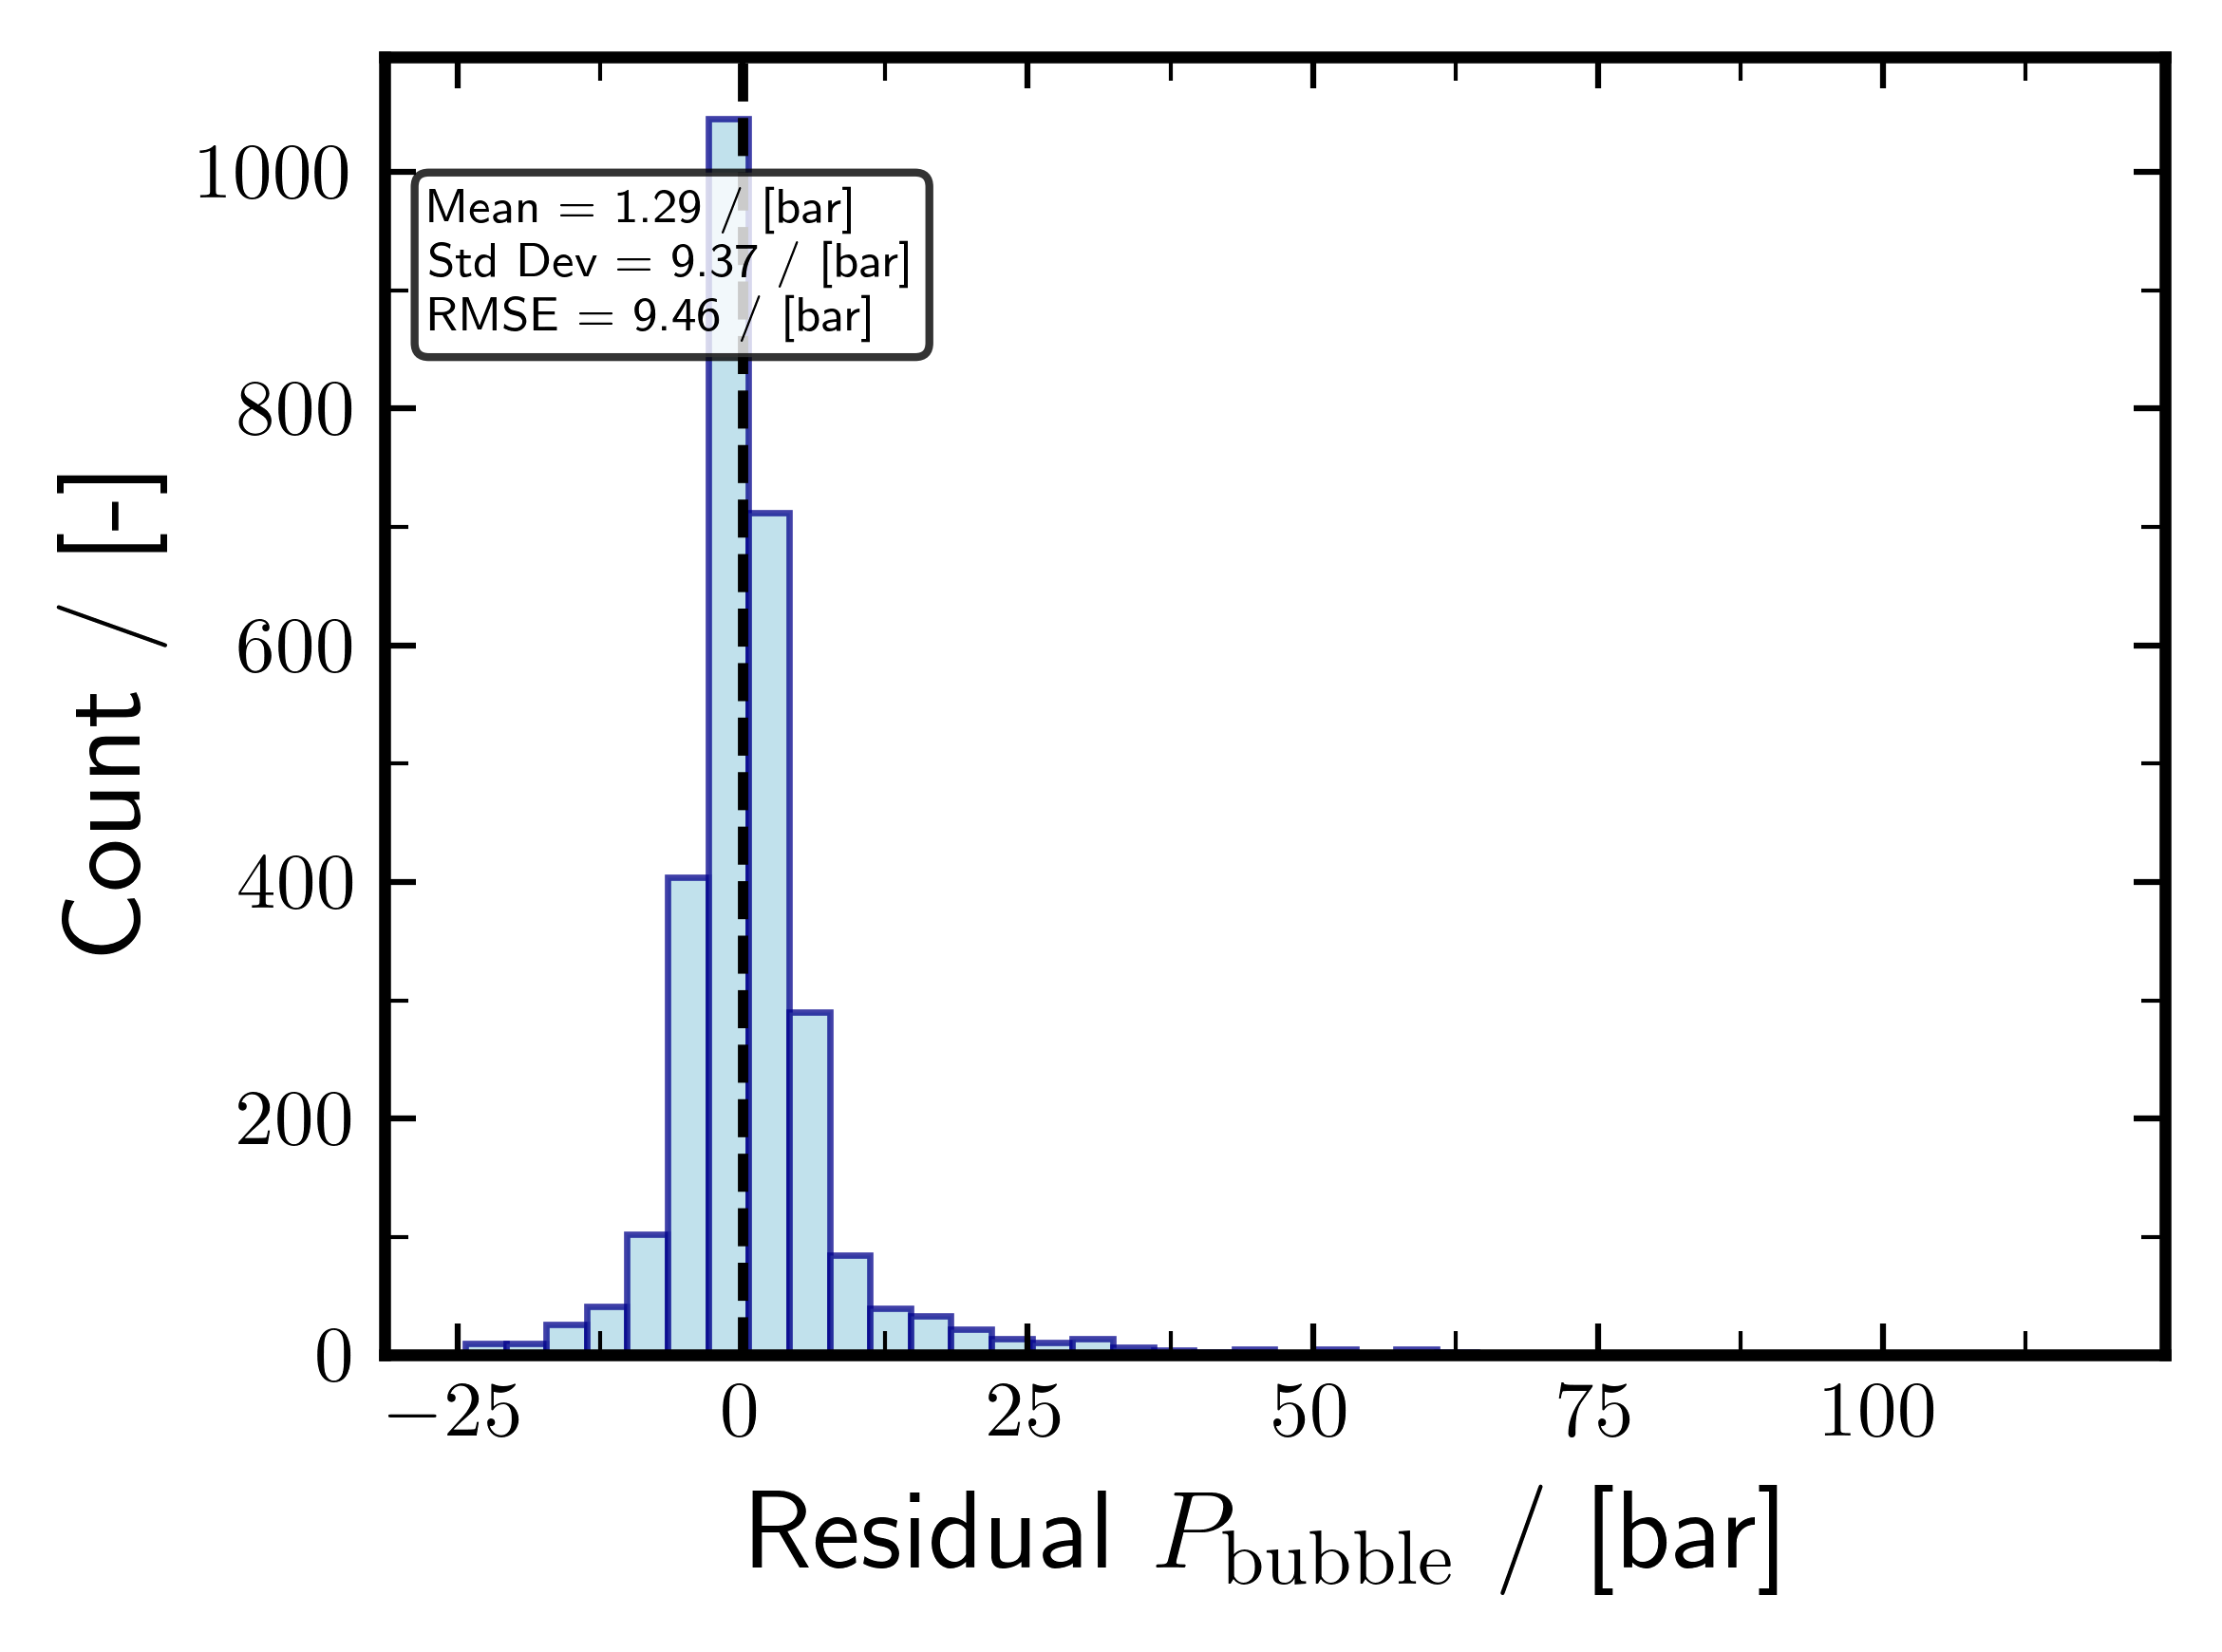

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Count / [-]'>)

In [18]:
# Residual distribution
post.plot_residual_distribution(save_path="SVM_P_bubble_residual_distribution", folder=OUTPUT_FOLDER)

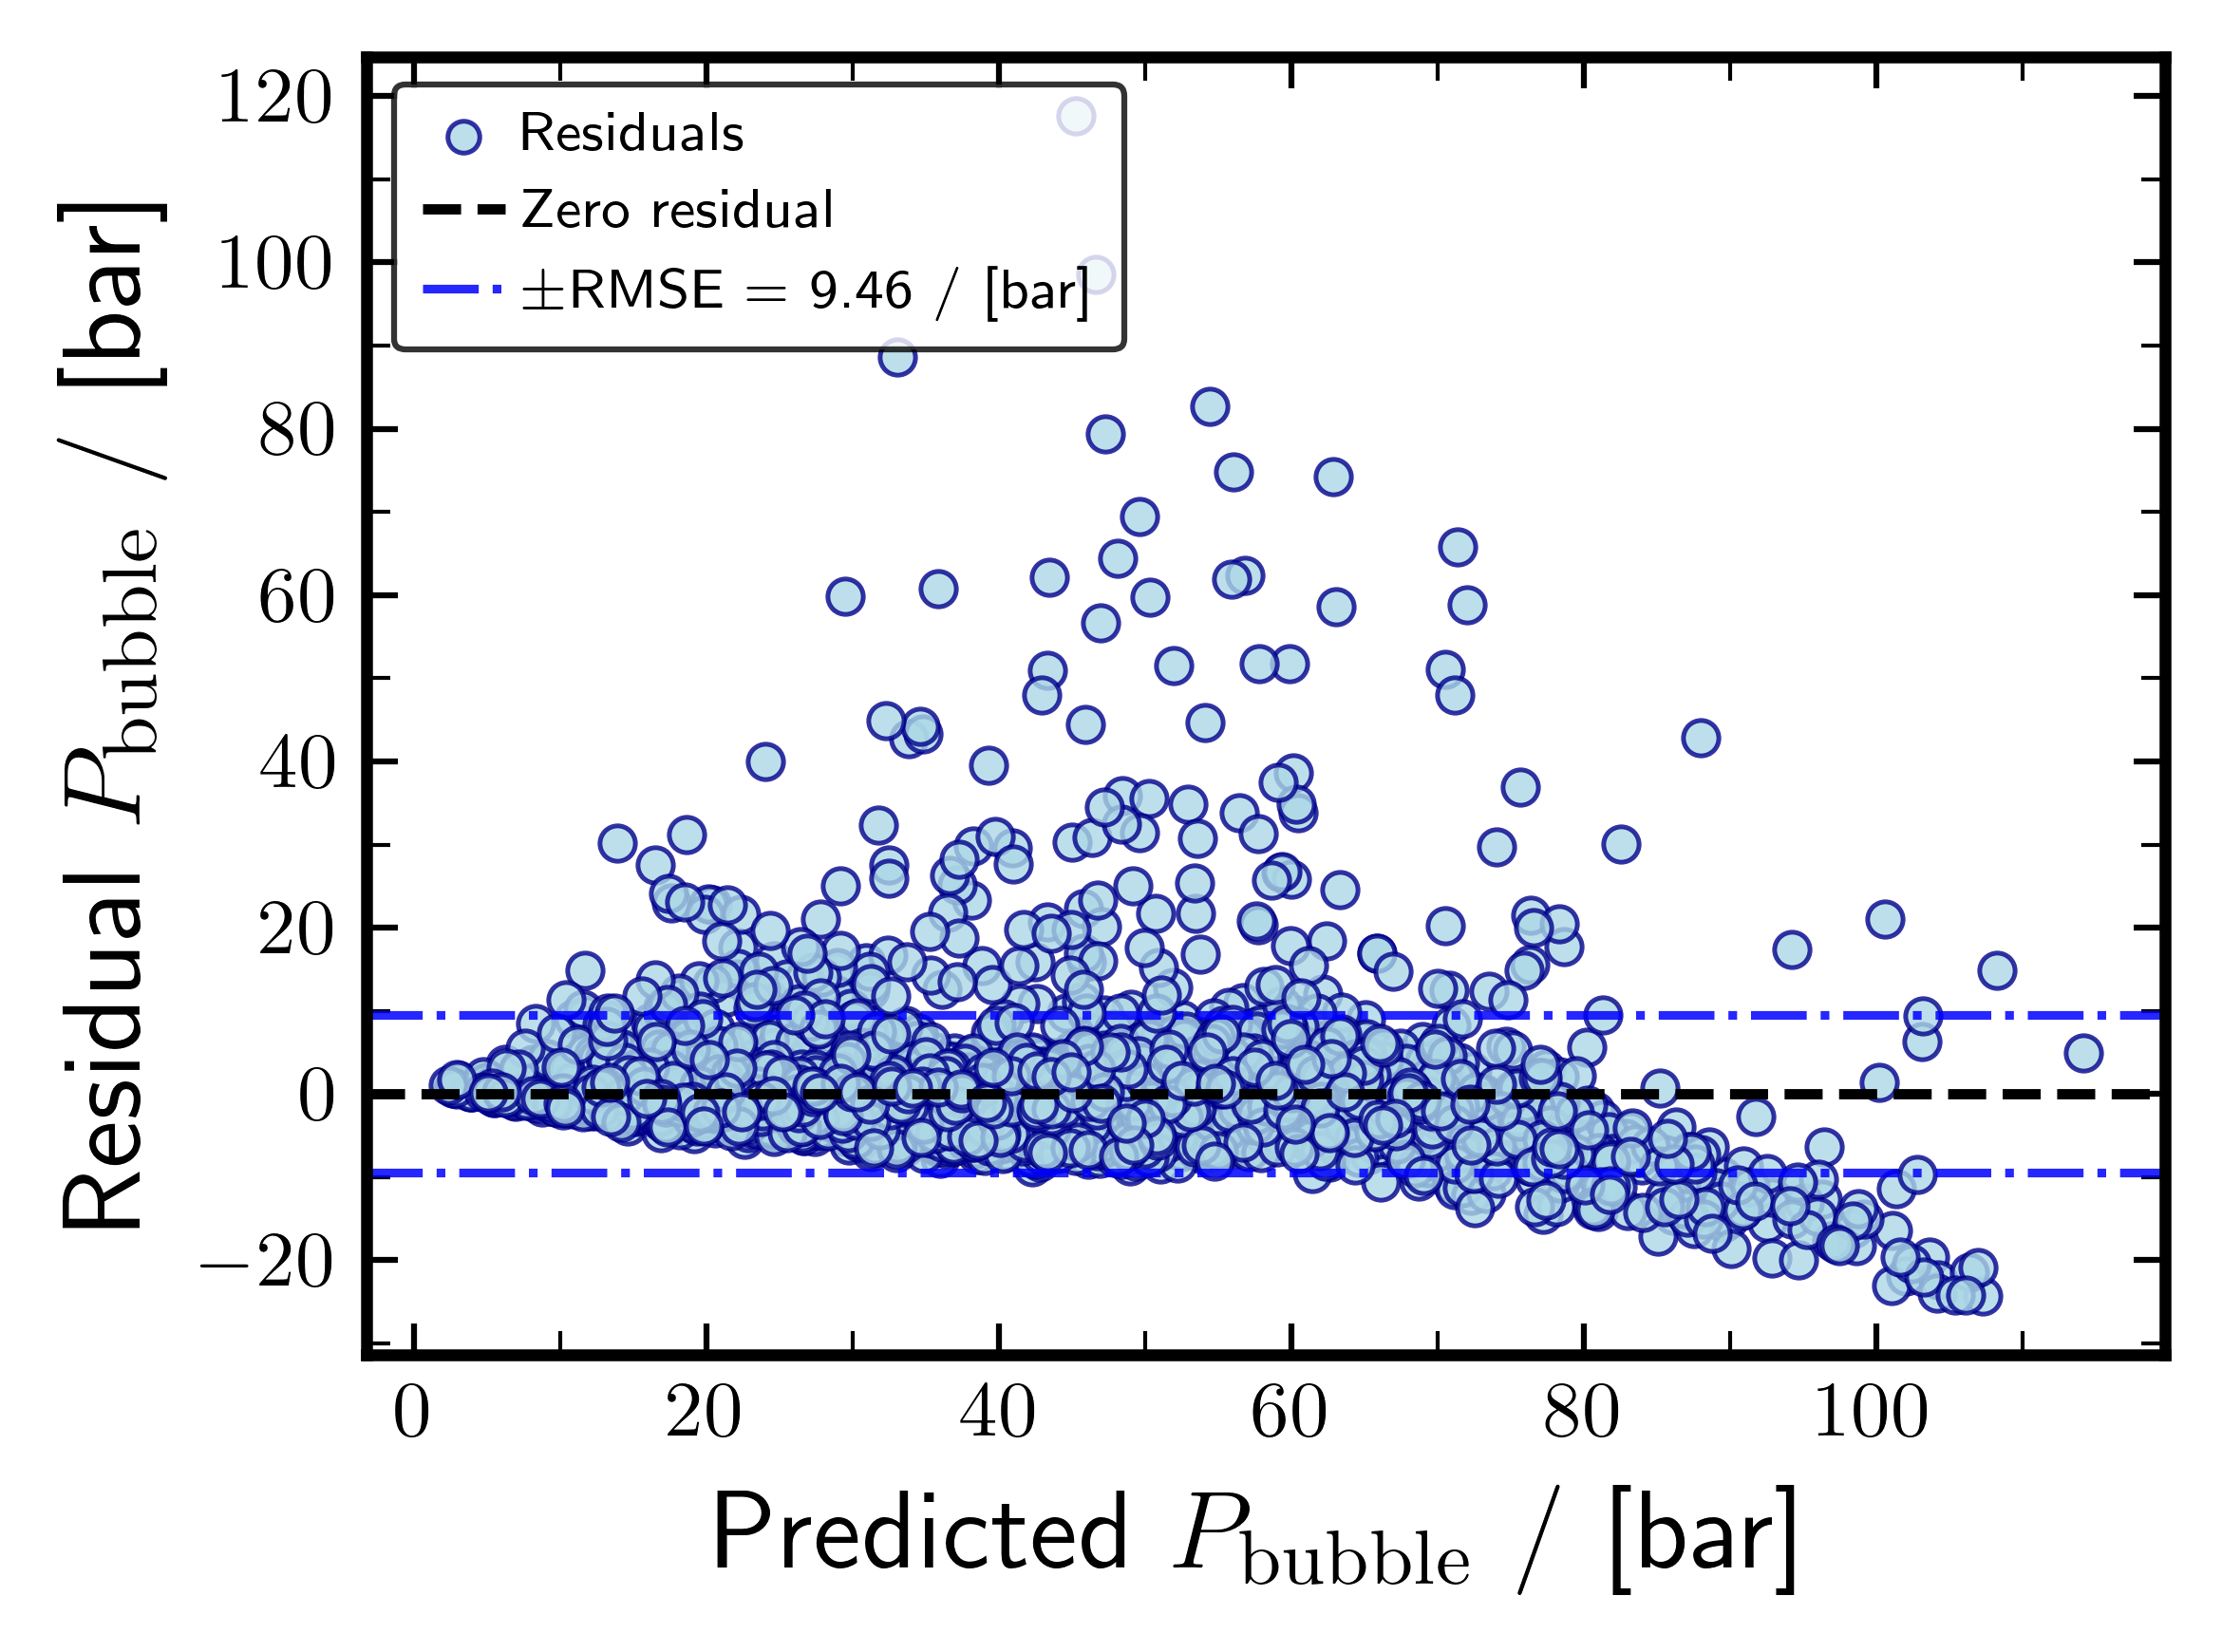

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Residual $P_{\\mathrm{bubble}}$ / [bar]'>)

In [19]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="SVM_P_bubble_residual_vs_predicted", folder=OUTPUT_FOLDER)

In [20]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]   = cv_r2_scores.tolist()
metrics["cv_r2_mean"]     = float(cv_r2_scores.mean())
metrics["cv_r2_std"]      = float(cv_r2_scores.std())
metrics["cv_rmse_scores"] = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]   = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]    = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]  = cv_mae_scores.tolist()
metrics["cv_mae_mean"]    = float(cv_mae_scores.mean())
metrics["cv_mae_std"]     = float(cv_mae_scores.std())
metrics["cv_mape_scores"] = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]   = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]    = float(cv_mape_scores.std() * 100)
metrics["n_support_vectors"]  = int(svm_model.named_steps["svr"].support_vectors_.shape[0])
metrics["sv_fraction"]        = float(svm_model.named_steps["svr"].support_vectors_.shape[0] / len(X_train))
metrics["C_sweep_values"]     = C_values
metrics["C_sweep_test_rmse"]  = test_rmse_C
metrics["eps_sweep_values"]   = eps_values
metrics["eps_sweep_test_rmse"]= test_rmse_eps
metrics["model"]          = "SVR_linear"
metrics["kernel"]         = svm_model.named_steps["svr"].kernel
metrics["C"]              = svm_model.named_steps["svr"].C
metrics["epsilon"]        = svm_model.named_steps["svr"].epsilon
metrics["features"]       = features
metrics["target"]         = target
metrics["seed"]           = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"SVM_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2904
R² Score:       0.813192
RMSE:           9.456108
MAE:            4.849878
Mean Residual:  1.291933
Std Residual:   9.367437

FEATURE IMPORTANCES:
------------------------------------------------------------
  pressure                  |  34.13% | █████████████████
  z_hydrogen                |  25.24% | ████████████
  temperature               |  16.12% | ████████
  z_carbon dioxide          |  10.80% | █████
  z_hydrogen sulfide        |   5.72% | ██
  z_methane                 |   3.70% | █
  z_nitrogen                |   3.02% | █
  z_argon                   |   0.90% | 
  z_oxygen                  |   0.25% | 
  z_carbon monoxide         |   0.12% | 

Metrics saved to: SLURM_Pbubble/SVM_P_bubble_metrics.json


In [21]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 30.03 minutes
